In [1]:
# i.i.d setting 

# Package 

In [2]:
import os
import json
import pdb
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from scipy.optimize import minimize
from scipy.stats import gaussian_kde

# Base learners
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

# Super Learner 
from sklearn.model_selection import KFold 
# Jump Diffusion 
from sklearn.preprocessing import StandardScaler

# Process Track 
from tqdm import tqdm



# Utilities 

In [3]:
def get_online_quantile(scores, q_1, etas, alpha):
    """
    Computes the online quantile of a set of scores.
    :param scores: (np.array) The scores.
    :param q_1: (float) The quantile to compute.
    :param eta: (np.array) The sequence of learning rates.
    :return: (float) The sequence of online quantiles.
    """
    T = scores.shape[0]
    q = np.zeros(T)
    q[0] = q_1
    for t in range(T):
        err_t = (scores[t] > q[t]).astype(int)
        if t < T - 1:
            q[t + 1] = q[t] - etas[t] * (alpha - err_t)
    return q

def compute_coverage_metrics(Y, Yhat, alpha, epsilon, W, C):
    """
    Compute online quantiles, observed coverages

    Parameters:
        scores (numpy array): Array of scores for the main dataset.
        scores_val (numpy array): Array of scores for the validation dataset.
        alpha (float): 1 - alpha is the desired coverage level.
        epsilon (float): Decay parameter for eta in the decaying quantile.
        W (int): Window size for rolling coverage computation.
        C: Constant of etas decaying 

    Returns:
        dict: Dictionary containing all computed metrics.
    """
    scores = np.abs(Y - Yhat)
    T = len(scores)
    
    # Define learning rates
    etas_decaying = C * (np.array([1 / (t ** (1 / 2 + epsilon)) for t in range(1, T + 1)]))
    
    # Initialize first quantile value
    q_1 = scores[0]

    # Compute online quantiles
    q_decaying = get_online_quantile(scores, q_1, etas_decaying, alpha)

    # Compute observed coverage
    observed_coverages_decaying = (scores <= q_decaying).astype(int)


    # Compute long-run coverage
    LRC_decaying = np.cumsum(observed_coverages_decaying) / (np.arange(len(observed_coverages_decaying)) + 1)

    return {
        "T":T,
        "q_decaying": q_decaying,
        "observed_coverages_decaying": observed_coverages_decaying,
        "LRC_decaying": LRC_decaying,

    }

def plot_coverage_results(results, alpha, W):
    """
    Plots the quantile evolution
    for a single dataset using results from compute_coverage_metrics.

    Parameters:
        results (dict): Dictionary output from compute_coverage_metrics.
        alpha (float): 1 - alpha is the desired coverage level.
        W (int): Window size for rolling coverage computation.

    Returns:
        None (Displays the plot).
    """

    T = results['T']

    sns.set_style("white")
    sns.set_palette("Set2")
    plt.figure(figsize=(6, 3))
    plt.plot(range(T), results["q_decaying"], label=r'$\eta_t = \frac{1}{t^{1/2+\epsilon}}$')
    plt.ylabel(r'$q_t$')
    plt.xlabel(r'time $t$')
    plt.legend()
    sns.despine(top=True, right=True)
    plt.tight_layout()
    plt.show()

    #  Long-run coverage 
    plt.figure(figsize=(6, 3))
    plt.plot(range(T), results["LRC_decaying"], label=r'$\eta_t = \frac{1}{t^{1/2+\epsilon}}$')
    plt.axhline(y= (1 - alpha), linestyle='dotted', color="k", linewidth=2, label=r'$1-\alpha$')
    plt.xlabel(r'time $t$')
    plt.ylabel("long-run coverage")
    plt.legend()
    sns.despine(top=True, right=True)
    plt.tight_layout()
    plt.show()


# COMA 

def hedge(loss_matrix, eta):
    """
    Hedge algorithm.

    Parameters
    ----------
    loss_matrix : np.ndarray
        Shape (N, K), loss of K experts during N rounds.
    eta : float
        Learning rate parameter.

    Returns
    -------
    dict
        h : np.ndarray of shape (N,)
            Weighted average loss at each round.
        weights : np.ndarray of shape (N, K)
            Expert weights at each round.
    """
    N, K = loss_matrix.shape
    h = np.full(N, np.nan)          # vector of length N
    weights = np.full((N, K), np.nan)  # N x K matrix
    w = np.full(K, 1.0 / K)         # start uniform weights

    for t in range(N):
        weights[t, :] = w
        w = w * np.exp(-eta * loss_matrix[t, :])  # exponential weighting
        w = w / np.sum(w)                         # normalize
        h[t] = np.sum(w * loss_matrix[t, :])      # weighted average loss

    return {"h": h, "weights": weights}


def counts_int(M, a, b, w):
    """
    Compute weighted fraction of intervals in M that cover the midpoint of [a,b].
    
    Parameters
    ----------
    M : np.ndarray
        Shape (n, 2), intervals with lower and upper bounds.
    a, b : float
        Interval boundaries.
    w : np.ndarray
        Weights for each interval (length n).
    
    Returns
    -------
    float
        Weighted mean (between 0 and 1).
    """
    mid = 0.5 * (a + b)
    inside = (M[:, 0] <= mid) & (mid <= M[:, 1]) 
    inside = inside.astype(float)                  
    num_int = np.average(inside, weights=w)
    return num_int


def mix(L, eta):
    """
    Python translation of R mix().
    """
    mn = np.min(L)

    if np.isinf(eta):
        w = (L == mn).astype(float)
        w /= w.sum()
    else:
        w = np.exp(-eta * (L - mn))

    s = np.sum(w)
    w = w / s
    M = mn - (1.0 / eta) * np.log(s / len(L)) if not np.isinf(eta) else mn

    return {"w": w, "M": M}

def adahedge(loss_matrix):
    N, K = loss_matrix.shape
    h = np.full(N, np.nan)
    L = np.zeros(K)
    etas = np.full(N, np.nan)
    weights = np.full((N, K), np.nan)
    Delta = 0.0

    for t in range(N):
        eta = np.log(K) / Delta if Delta > 0 else np.inf
        result = mix(L, eta=eta)
        w, Mprev = result["w"], result["M"]

        h[t] = np.dot(w, loss_matrix[t])
        weights[t] = w
        L = L + loss_matrix[t]

        result = mix(L, eta=eta)
        delta = max(0.0, h[t] - (result["M"] - Mprev))
        Delta += delta
        etas[t] = eta

    return {"h": h, "weights": weights, "eta": etas}



def majority_vote(M, w, rho):
    breaks = np.unique(M.flatten())
    breaks.sort()

    lower, upper = [], []

    if np.mean(np.isinf(M[:, 1])) > rho:
        return np.array([[-np.inf, np.inf]])

    i = 0
    while i < len(breaks) - 1:
        cond = counts_int(M, breaks[i], breaks[i+1], w) > rho
        if cond:
            lower.append(breaks[i])
            j = i
            while j < len(breaks) - 1 and cond:
                j += 1
                if j < len(breaks) - 1:   
                    cond = counts_int(M, breaks[j], breaks[j+1], w) > rho
                else:
                    cond = False
            upper.append(breaks[j])
            i = j
        i += 1

    if not lower:
        return np.nan
    else:
        return np.column_stack([lower, upper])


def covr_fun(ci, target):
    """
    Coverage function: check if target lies inside interval(s).
    
    ci: np.ndarray (L, 2) or (2,), interval(s)
    target: float, true value
    
    Returns: 1 if covered, 0 otherwise
    """
    if isinstance(ci, float) and np.isnan(ci):
        return 0

    ci = np.atleast_2d(ci)
    covr = 0
    for l, u in ci:
        covr += int((l <= target) and (target <= u))
    return covr

import numpy as np

def loss_fun(ci):
    """
    Compute the width of confidence interval(s).
    
    Parameters
    ----------
    ci : np.ndarray or list
         - shape (2,)   → single interval [low, high]
         - shape (L, 2) → multiple intervals
         - np.nan       → no interval
    
    Returns
    -------
    float
        total width (sum of all intervals' widths)
    """

    if ci is None or (isinstance(ci, float) and np.isnan(ci)):
        return 0.0
    ci = np.atleast_2d(ci)
    
    width = 0.0
    for l, u in ci:
        if np.isnan(l) or np.isnan(u):
            continue
        width += (u - l)
    return width

import numpy as np

def coma_loop(intervals_list, weights, data_y):
    """
    COMA aggregation loop (Python translation of the R code).
    
    intervals_list: list of arrays [N x 2], one for each expert's intervals
    weights: array [N x K], AdaHedge weights
    data_y: array of true outcomes
    """
    N, K = weights.shape
    pi_m, pi_wm = [], []
    m_cov, wm_cov = [], []

    for i in range(N):
        # stack intervals from all experts for round i
        conf_t = np.vstack([intervals[i] for intervals in intervals_list])

        # deterministic majority vote (rho=0.5 for strict majority)
        maj_int = majority_vote(conf_t, w=weights[i], rho=0.5)

        # randomized majority vote (rho ∈ [0.5,1])
        rho_rand = np.random.uniform(0.5, 1.0)
        wmaj_int = majority_vote(conf_t, w=weights[i], rho=rho_rand)

        # store intervals
        pi_m.append(maj_int)
        pi_wm.append(wmaj_int)

        # coverage check (ensure index alignment!)
        target_idx = i
        if target_idx < len(data_y):
            m_cov.append(covr_fun(maj_int, data_y[target_idx]))
            wm_cov.append(covr_fun(wmaj_int, data_y[target_idx]))
        else:
            m_cov.append(0)
            wm_cov.append(0)

    return {
        "pi_m": pi_m,
        "pi_wm": pi_wm,
        "m_cov": np.array(m_cov),
        "wm_cov": np.array(wm_cov),
        "mean_m_cov": np.mean(m_cov),
        "mean_wm_cov": np.mean(wm_cov)
    }

# smooth
def smooth_series(series, window=500):
    return np.convolve(series, np.ones(window)/window, mode='valid')

# Simple average ensemble 

def simple_average_ensemble(predictions):
    """
    Simple average ensemble of multiple model predictions.

    Parameters:
        predictions (list of np.array): List of prediction arrays from different models.

    Returns:
        np.array: Ensemble predictions obtained by averaging.
    """
    return np.mean(predictions, axis=0)

def plot_density(y_true, y_pred, title, label_pred):
    kde_pred = gaussian_kde(y_pred)

    x_min = min(y_true.min(), y_pred.min())
    x_max = max(y_true.max(), y_pred.max())
    x_grid = np.linspace(x_min, x_max, 500)

    plt.figure(figsize=(6, 4))
    plt.plot(x_grid, kde_pred(x_grid), label=label_pred, linewidth=2, linestyle="--")

    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [4]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

airbnb = pd.read_csv(
    "ny_airbnb.txt",
    sep=None, engine="python"
)

cols = [
    "price",
    "latitude",
    "longitude",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "extra_people",
    "minimum_nights",
    "maximum_nights",
    "number_of_reviews",
    "review_scores_rating",
    "review_scores_accuracy",
    "reviews_per_month",
    "aggressioni_1000",
    "droga_1000",
    "furti_1000",
]

airbnb = airbnb[cols].dropna().reset_index(drop=True)
airbnb = airbnb[airbnb["price"] > 0].reset_index(drop=True)
y = np.log(airbnb["price"].to_numpy(dtype=float))
X = airbnb.drop(columns=["price"]).to_numpy(dtype=float)
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 80/20 split
    random_state=123,
    shuffle=True
)

print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0], "  #features:", X_train.shape[1])

Train size: 62170  Test size: 15543   #features: 15


# Base Learners

In [5]:

# LM
lm_funs = {
    "train": lambda X, y: LinearRegression().fit(X, y),
    "predict": lambda model, Xnew: model.predict(Xnew)
}

# Ridge
ridge_funs = {
    "train": lambda X, y: Ridge(alpha=0.1, fit_intercept=True).fit(X, y),
    "predict": lambda model, Xnew: model.predict(Xnew)
}

# Lasso
lasso_funs = {
    "train": lambda X, y: Lasso(alpha=0.1, fit_intercept=True, max_iter=5000).fit(X, y),
    "predict": lambda model, Xnew: model.predict(Xnew)
}

# NNET
nnet_funs = {
    "train": lambda X, y: MLPRegressor(
        hidden_layer_sizes=(8,),
        activation="tanh",
        alpha=1.0,
        max_iter=2000,
        solver="adam",
        random_state=123
    ).fit(X, y),
    "predict": lambda model, Xnew: model.predict(Xnew)
}

# RF
rf_funs = {
    "train": lambda X, y: RandomForestRegressor(
        n_estimators=250,
        max_features=4/16,
        bootstrap=True,
        n_jobs=-1,
        random_state=123
    ).fit(X, y),
    "predict": lambda model, Xnew: model.predict(Xnew)
}

funs = [rf_funs, lm_funs, lasso_funs, ridge_funs, nnet_funs]

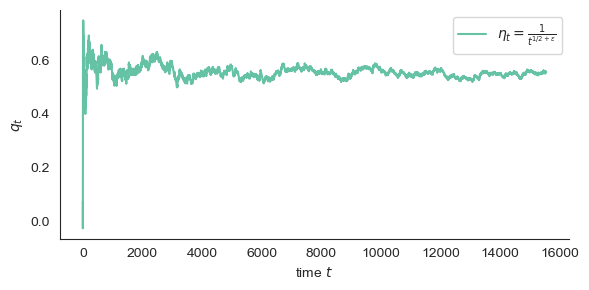

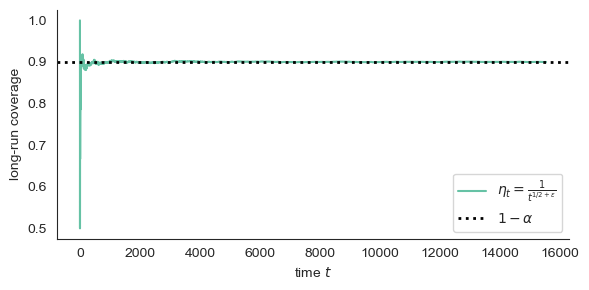

CI width for rf 0.9000193012931866


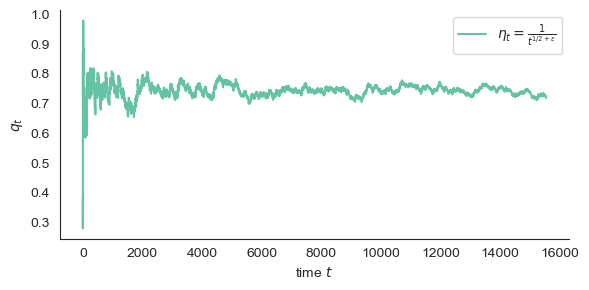

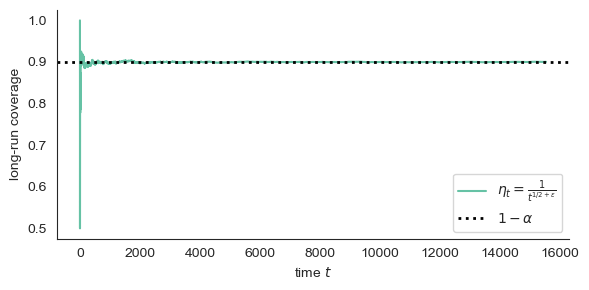

CI width for lm 0.9004053271569196


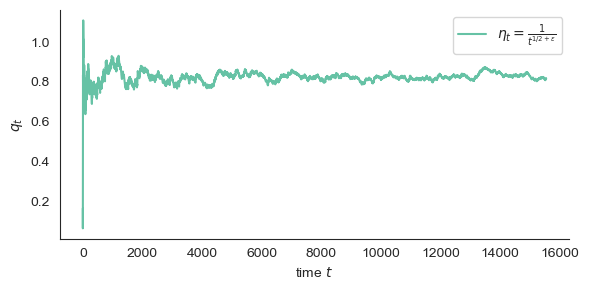

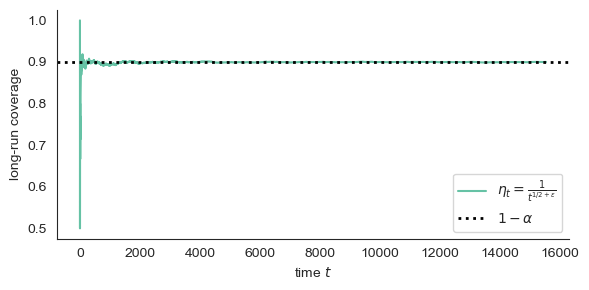

CI width for lasso 0.9000193012931866


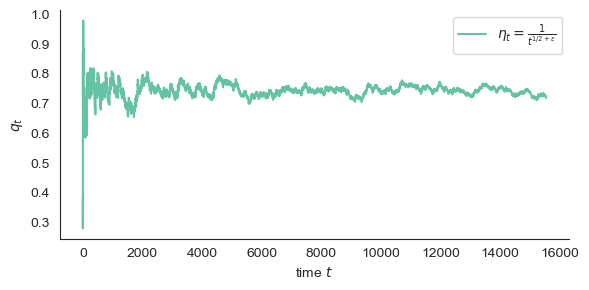

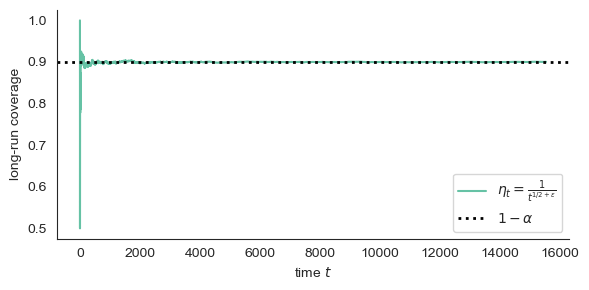

CI width for ridge 0.9004053271569196


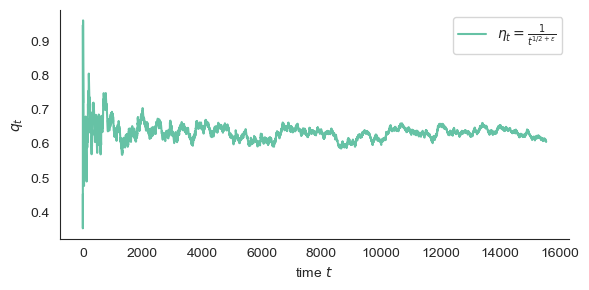

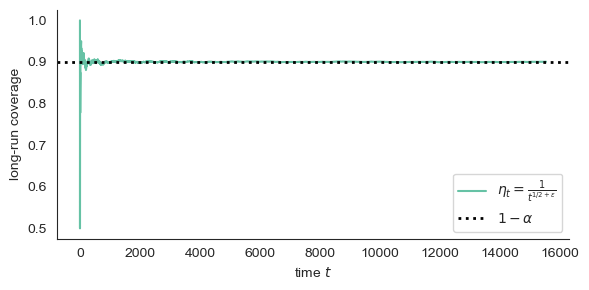

CI width for nnet 0.9005983400887859
Shapes: (15543,) (15543,) (15543,) (15543,) (15543,) (15543,)
CI width for rf 0.9000193012931866
CI width for lm 0.9004053271569196
CI width for lasso 0.9000193012931866
CI width for ridge 0.9004053271569196
CI width for nnet 0.9005983400887859


In [6]:

# y_true
y_true = y_test.astype(float)

# 1) Random Forest
rf_model = rf_funs["train"](X_train, y_train)             
y_pred_rf = rf_funs["predict"](rf_model, X_test)    
rf_results = compute_coverage_metrics(y_true, y_pred_rf, alpha=0.1, epsilon=0.1, W=50, C=1.0)
CI_rf_decaying = rf_results['q_decaying'] * 2
plot_coverage_results(rf_results, alpha=0.1, W=1000)
print(f"CI width for rf", np.mean(rf_results['observed_coverages_decaying']))

# 2) Linear Regression
lm_model = lm_funs["train"](X_train, y_train)
y_pred_lm = lm_funs["predict"](lm_model, X_test)
lm_results = compute_coverage_metrics(y_true, y_pred_lm, alpha=0.1, epsilon=0.1, W=50, C=1.0)
CI_lm_decaying = lm_results['q_decaying'] * 2
plot_coverage_results(lm_results, alpha=0.1, W=1000)
print(f"CI width for lm", np.mean(lm_results['observed_coverages_decaying']))

# 3) Lasso
lasso_model = lasso_funs["train"](X_train, y_train)
y_pred_lasso = lasso_funs["predict"](lasso_model, X_test)
lasso_results = compute_coverage_metrics(y_true, y_pred_lasso, alpha=0.1, epsilon=0.1, W=50, C=1.0)
CI_lasso_decaying = lasso_results['q_decaying'] * 2
plot_coverage_results(lasso_results, alpha=0.1, W=1000)
print(f"CI width for lasso", np.mean(lasso_results['observed_coverages_decaying']))

# 4) Ridge
ridge_model = ridge_funs["train"](X_train, y_train)
y_pred_ridge = ridge_funs["predict"](ridge_model, X_test)
ridge_results = compute_coverage_metrics(y_true, y_pred_ridge, alpha=0.1, epsilon=0.1, W=50, C=1.0)
CI_ridge_decaying = ridge_results['q_decaying'] * 2
plot_coverage_results(ridge_results, alpha=0.1, W=1000)
print(f"CI width for ridge", np.mean(ridge_results['observed_coverages_decaying']))

#5) NNET (MLPRegressor)
nnet_model = nnet_funs["train"](X_train, y_train)
y_pred_nnet = nnet_funs["predict"](nnet_model, X_test)
nnet_results = compute_coverage_metrics(y_true, y_pred_nnet, alpha=0.1, epsilon=0.1, W=50, C=1.0)
CI_nnet_decaying = nnet_results['q_decaying'] * 2
plot_coverage_results(nnet_results, alpha=0.1, W=1000)
print(f"CI width for nnet", np.mean(nnet_results['observed_coverages_decaying']))

print("Shapes:", y_true.shape, y_pred_rf.shape, y_pred_lm.shape, y_pred_lasso.shape, y_pred_ridge.shape, y_pred_nnet.shape)

print(f"CI width for rf", np.mean(rf_results['observed_coverages_decaying']))
print(f"CI width for lm", np.mean(lm_results['observed_coverages_decaying']))
print(f"CI width for lasso", np.mean(lasso_results['observed_coverages_decaying']))
print(f"CI width for ridge", np.mean(ridge_results['observed_coverages_decaying']))
print(f"CI width for nnet", np.mean(nnet_results['observed_coverages_decaying']))

# Simple Average 

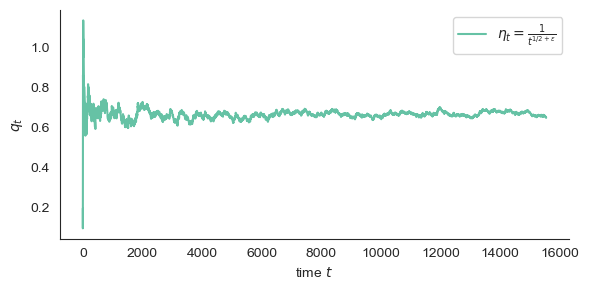

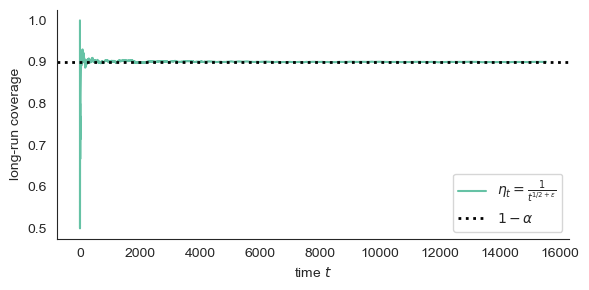

0.6652270598056481


In [7]:
y_sa_pred = simple_average_ensemble([y_pred_rf, y_pred_lm, y_pred_lasso, y_pred_ridge, y_pred_nnet])
results_sa = compute_coverage_metrics(y_true, y_sa_pred, alpha=0.1, epsilon=0.1, W=1000, C=1)
plot_coverage_results(results_sa, alpha=0.1, W=1000)
print(np.mean(results_sa['q_decaying']))
CI_sa_decaying = results_sa['q_decaying'] * 2

# Super Learner 

Fold 0: train=49736, val=12434
Fold 1: train=49736, val=12434
Fold 2: train=49736, val=12434
Fold 3: train=49736, val=12434
Fold 4: train=49736, val=12434
First meta-learner weights: [1.00000000e+00 0.00000000e+00 1.12757026e-17 1.38777878e-17
 0.00000000e+00]


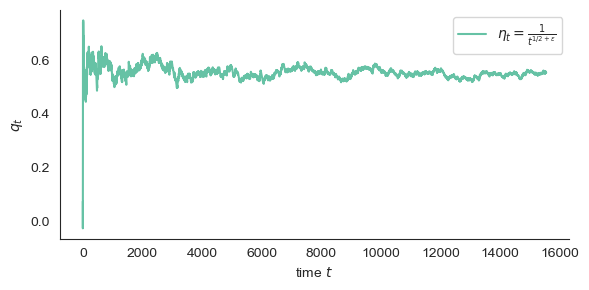

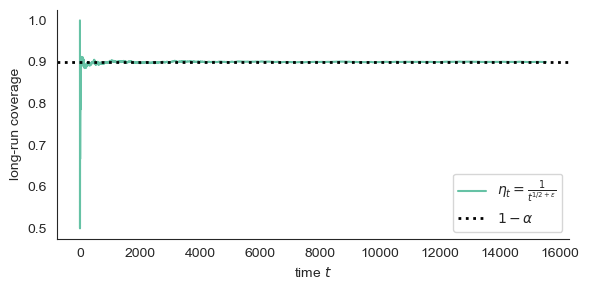

mean coverage for Super Learner is: 0.9000193012931866


In [8]:
def optimize_weights(X, y, alpha1=0.0, alpha2=0.0):
    init_phi = np.ones(X.shape[1]) / X.shape[1]
    def mse_loss(phi):
        y_pred = X @ phi
        mse = np.mean((y - y_pred) ** 2)
        l1 = alpha1 * np.sum(np.abs(phi))
        l2 = alpha2 * np.sum(phi**2)
        return mse + l1 + l2
    constraints = [{'type': 'eq', 'fun': lambda phi: np.sum(phi) - 1}]
    bounds = [(0, 1)] * X.shape[1]
    result = minimize(mse_loss, init_phi, bounds=bounds, constraints=constraints)
    return result.x


def base_preds(train_idx, val_idx, X, y, funs):
    """
    Train each learner on X[train_idx], y[train_idx]
    Predict on X[val_idx]
    Returns: (len(val_idx), K) matrix
    """
    Xtr, ytr = X[train_idx], y[train_idx]
    Xva      = X[val_idx]
    K = len(funs)

    preds = np.zeros((len(val_idx), K))
    for j, z in enumerate(funs):
        model = z["train"](Xtr, ytr)
        preds[:, j] = z["predict"](model, Xva)

    return preds


def super_learner_iid(X_train, y_train, X_test, y_test, funs, n_splits=5, random_state=123):

    X_train = np.asarray(X_train, dtype=float)
    y_train = np.asarray(y_train, dtype=float).ravel()
    X_test  = np.asarray(X_test,  dtype=float)
    y_test  = np.asarray(y_test,  dtype=float).ravel()

    n = len(y_train)
    K = len(funs)
    T_test = X_test.shape[0]

    meta_features = np.full((n, K), np.nan, dtype=float)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    # Cross-validation 
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        print(f"Fold {fold}: train={len(train_idx)}, val={len(val_idx)}")
        preds_val = base_preds(train_idx, val_idx, X_train, y_train, funs)
        meta_features[val_idx, :] = preds_val

    valid = ~np.isnan(meta_features).any(axis=1)
    Z_full = meta_features[valid].astype(float)   # (n_eff, K)
    Y_full = y_train[valid].astype(float)         # (n_eff,)

    # meta-learner weight
    meta_weights = optimize_weights(Z_full, Y_full)
    print("First meta-learner weights:", meta_weights)
    # Retrain on full dataset 
    X_meta_full = np.zeros((T_test, K), dtype=float)
    for j, z in enumerate(funs):
        model = z["train"](X_train, y_train)
        X_meta_full[:, j] = np.asarray(z["predict"](model, X_test), dtype=float).ravel()

    # NNLS with online updating 
    super_preds  = np.zeros(T_test, dtype=float)
    weights_hist = np.zeros((T_test, K), dtype=float)

    w = meta_weights.copy()
    for t in range(T_test):
        if t > 0:
            w = optimize_weights(X_meta_full[:t], y_test[:t])

        super_preds[t]  = float(X_meta_full[t] @ w)
        weights_hist[t] = w

    return super_preds, weights_hist

super_preds, weights_hist = super_learner_iid(
    X_train, y_train, X_test, y_test, funs, n_splits=5
)

sl_results = compute_coverage_metrics(
    y_test, super_preds,
    alpha=0.1, epsilon=0.1, W=1000, C=1
)
plot_coverage_results(sl_results, alpha=0.1, W=1000)
CI_sl_decaying = sl_results['q_decaying'] * 2
print(f'mean coverage for Super Learner is:', np.mean(sl_results['observed_coverages_decaying']))

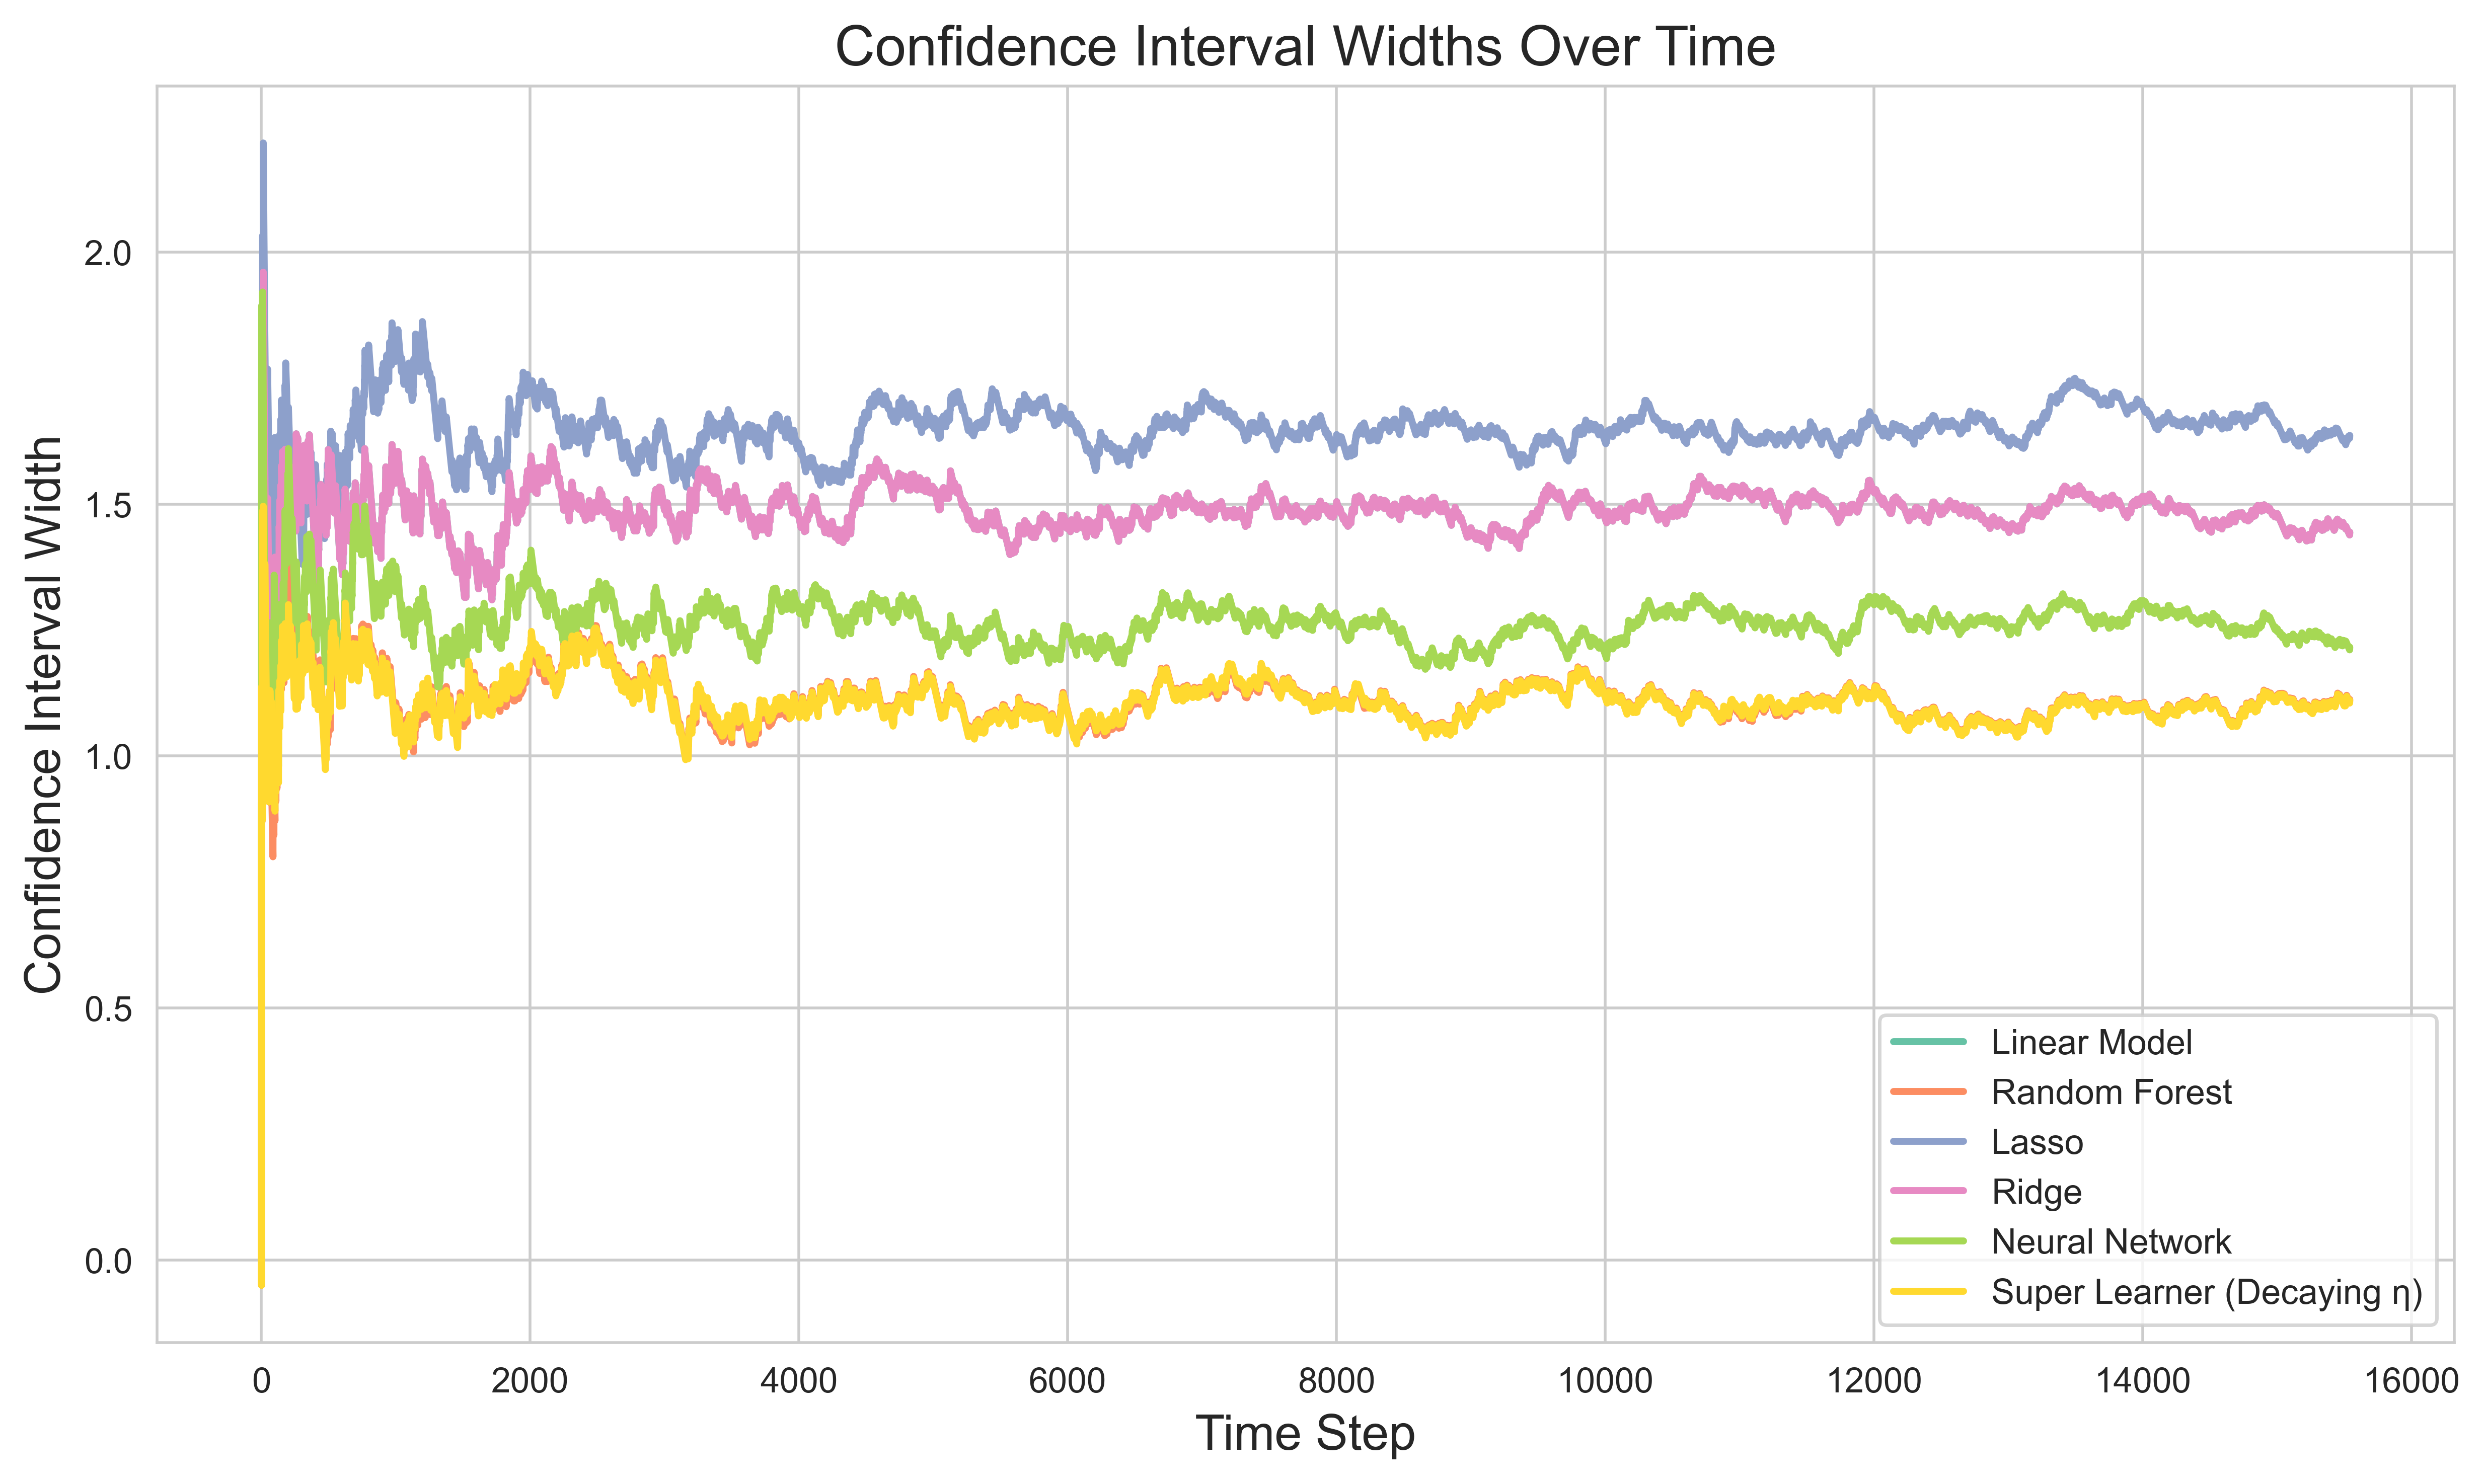

In [9]:
## line comparison plot 

n = len(CI_lm_decaying)
x = list(range(n))  # n is the number of CI values
plt.figure(figsize=(10, 6), dpi=500)
sns.set_style("whitegrid")
plt.plot(x, CI_lm_decaying[-n:], label='Linear Model', linewidth=2)
plt.plot(x, CI_rf_decaying[-n:], label='Random Forest', linewidth=2)
plt.plot(x, CI_lasso_decaying[-n:], label='Lasso', linewidth=2)
plt.plot(x, CI_ridge_decaying[-n:], label='Ridge', linewidth=2)
plt.plot(x, CI_nnet_decaying[-n:], label='Neural Network', linewidth=2)
plt.plot(x, CI_sl_decaying[-n:], label='Super Learner (Decaying η)', linewidth=2)

plt.title('Confidence Interval Widths Over Time', fontsize=16)
plt.xlabel('Time Step', fontsize=14)
plt.ylabel('Confidence Interval Width', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()


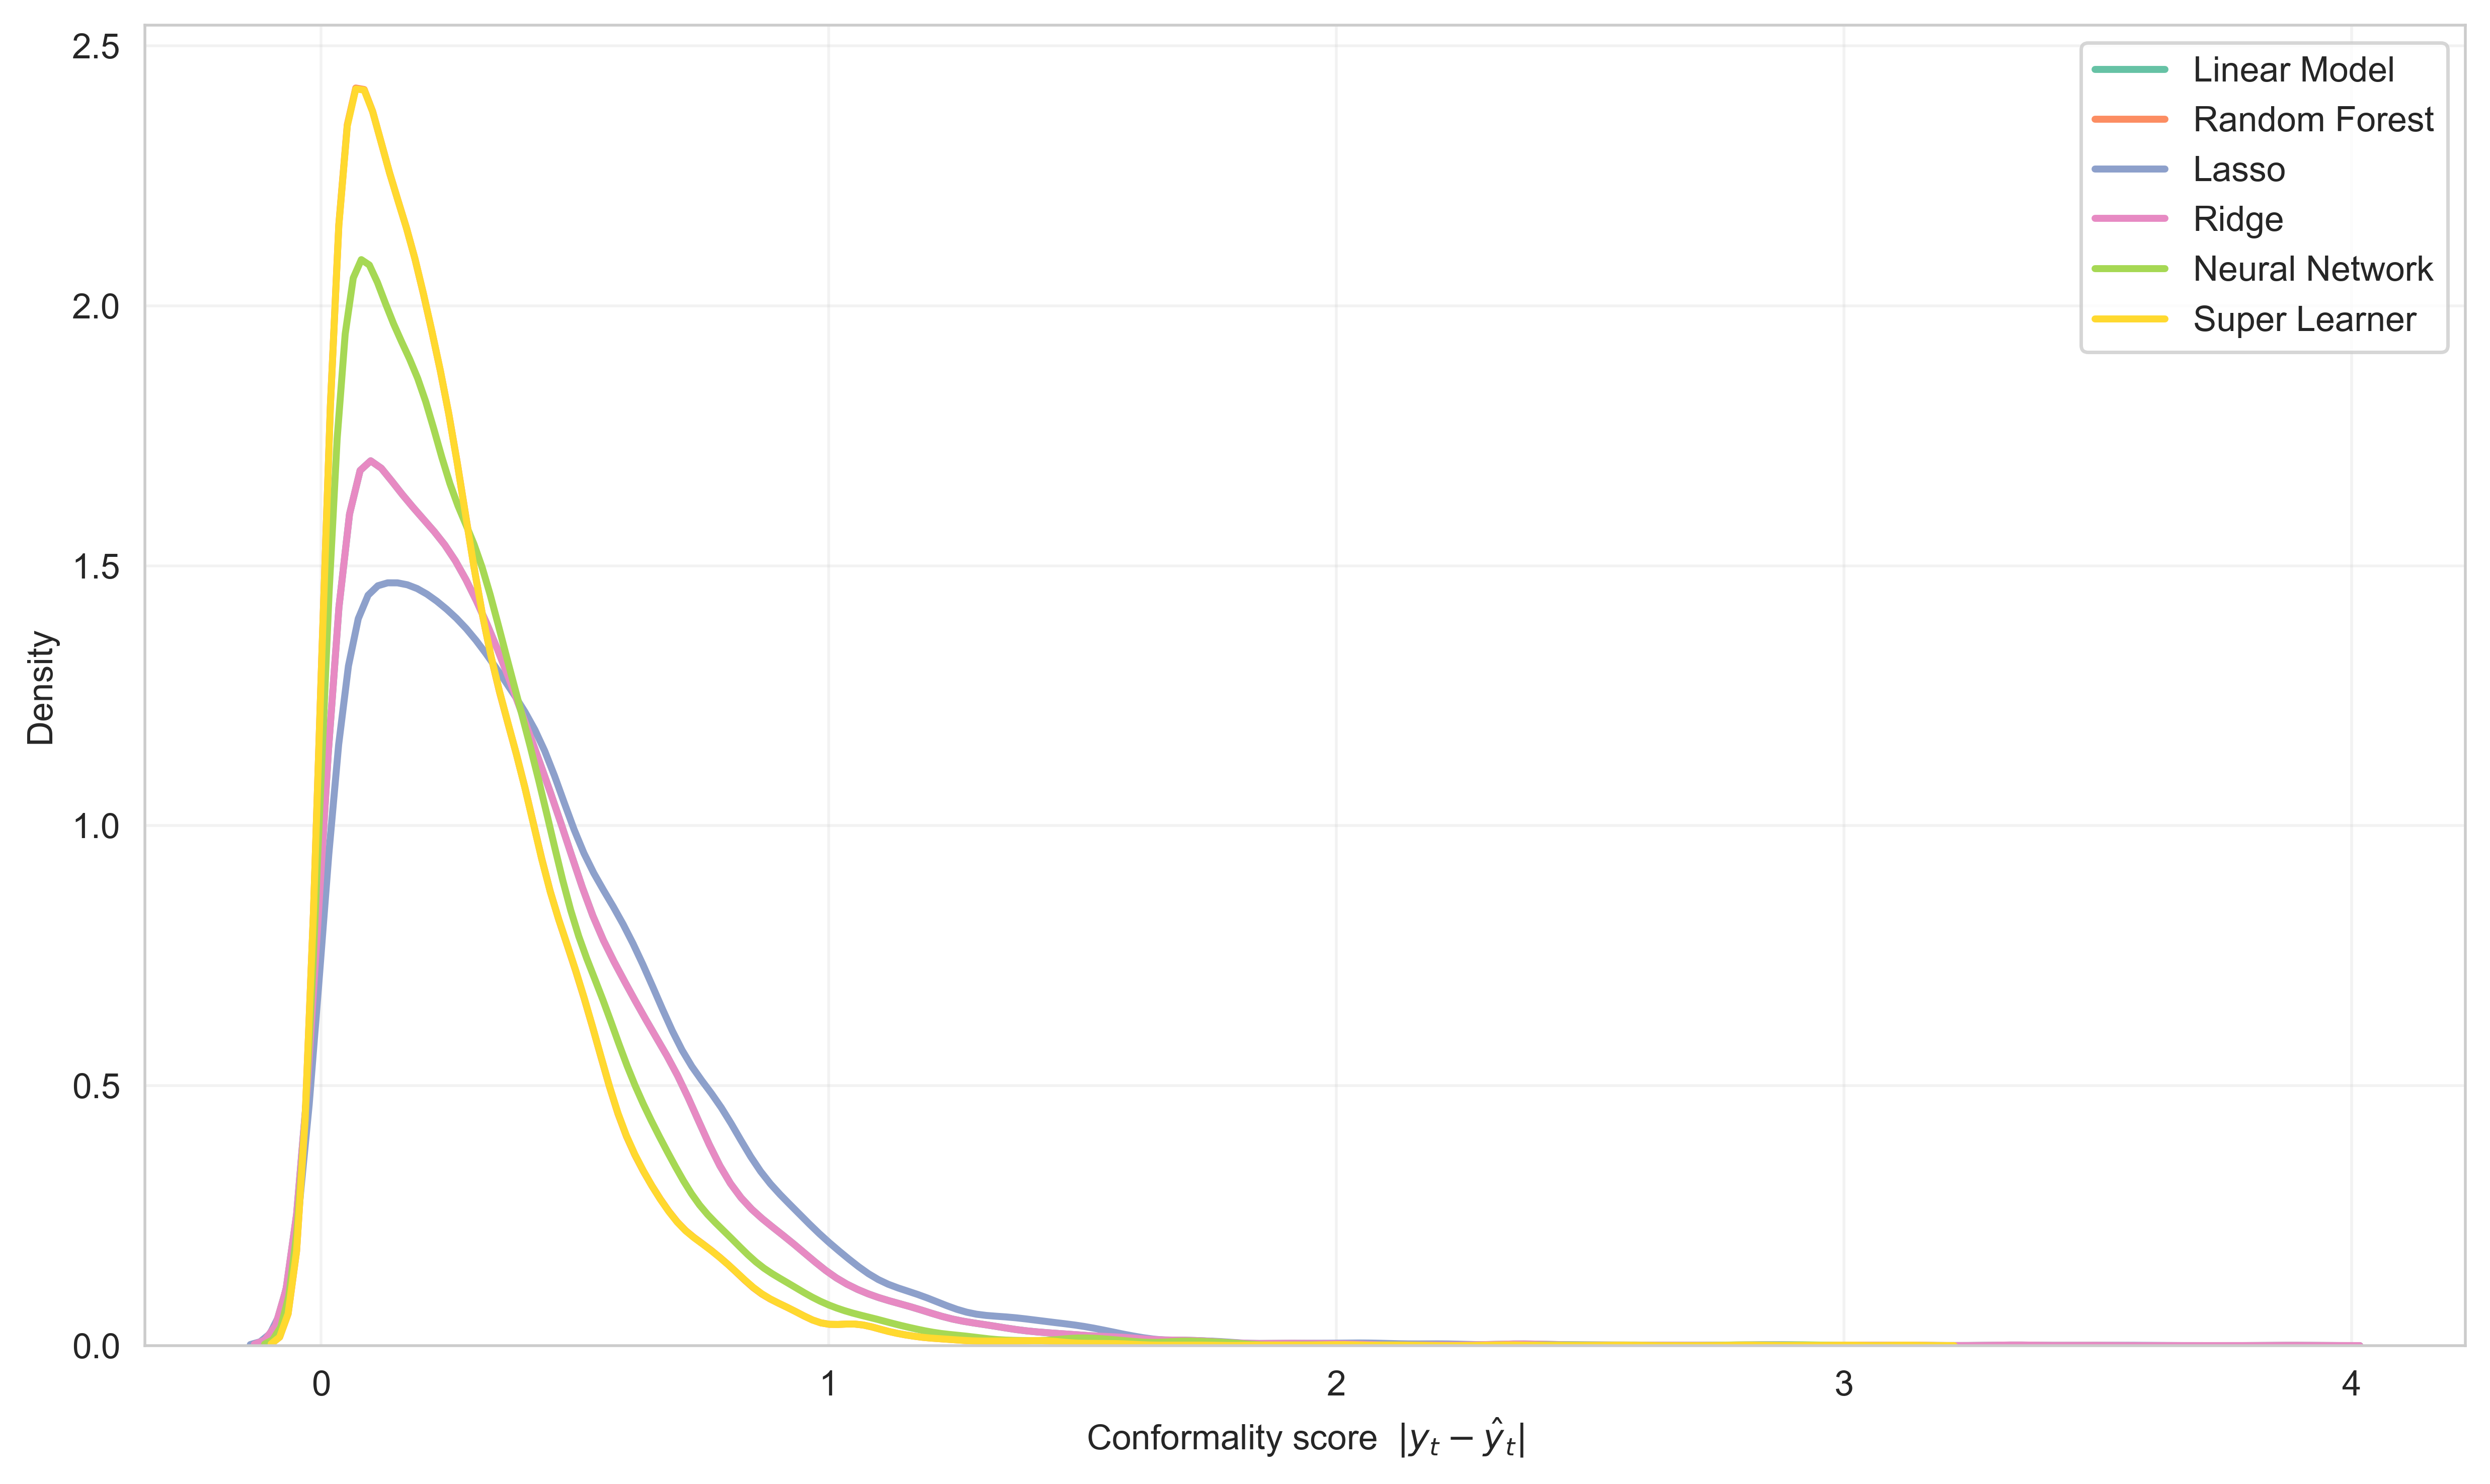

In [10]:

# Conformality scores
score_lm = np.abs(y_true - y_pred_lm)
score_rf = np.abs(y_true - y_pred_rf)
score_lasso = np.abs(y_true - y_pred_lasso)
score_ridge = np.abs(y_true - y_pred_ridge)
score_nnet = np.abs(y_true - y_pred_nnet)
score_sl = np.abs(y_true - super_preds)

plt.figure(figsize=(10, 6), dpi=500)

sns.kdeplot(score_lm, label="Linear Model", linewidth=2)
sns.kdeplot(score_rf, label="Random Forest", linewidth=2)
sns.kdeplot(score_lasso, label="Lasso", linewidth=2)
sns.kdeplot(score_ridge, label="Ridge", linewidth=2)
sns.kdeplot(score_nnet, label="Neural Network", linewidth=2)
sns.kdeplot(score_sl, label="Super Learner", linewidth=2)

plt.xlabel("Conformality score  $|y_t - \hat y_t|$")
plt.ylabel("Density")
#plt.title("Airbnb (i.i.d): Density of Conformality Scores")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("iid_score_density.png", dpi=500, bbox_inches="tight")
plt.show()

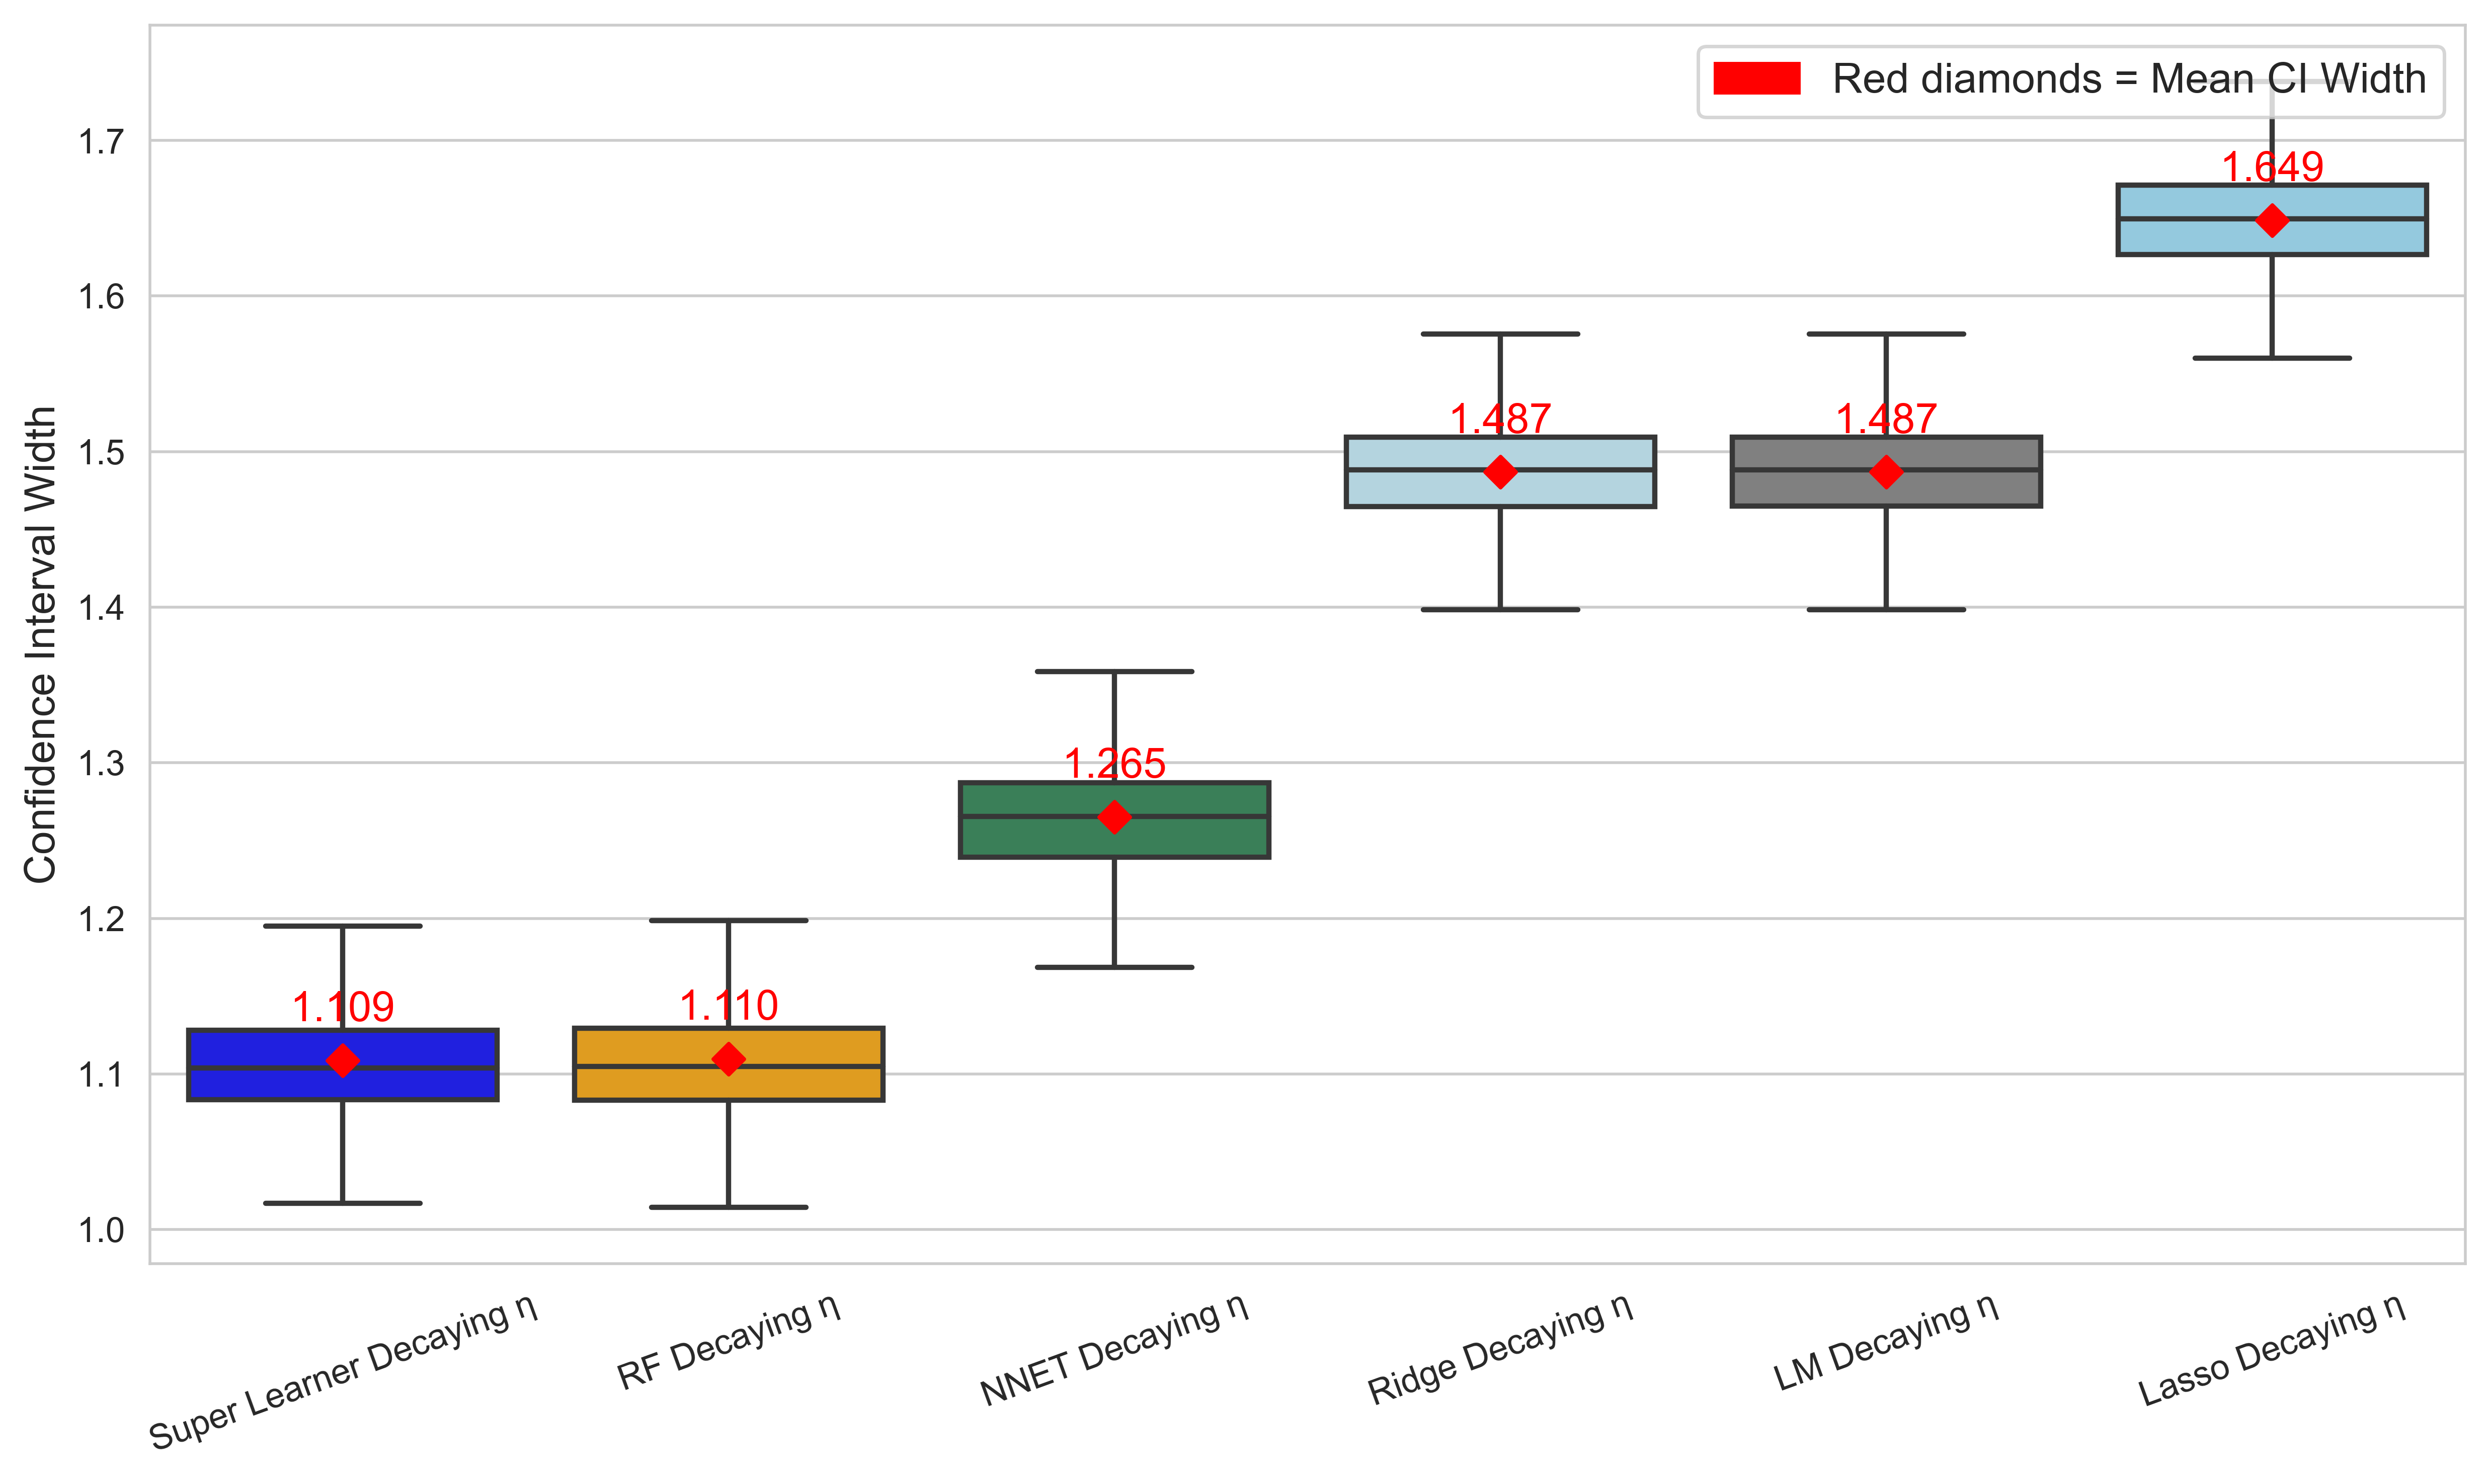

In [11]:

data_dict = {
    "LM Decaying η": CI_lm_decaying,
    "RF Decaying η": CI_rf_decaying,
    "Lasso Decaying η": CI_lasso_decaying,
    "Ridge Decaying η": CI_ridge_decaying,
    "NNET Decaying η": CI_nnet_decaying,
    "Super Learner Decaying η": CI_sl_decaying
}

df_box = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data_dict.items()]))
df_long = df_box.melt(var_name="Method", value_name="CI Width")
order = df_long.groupby("Method")["CI Width"].median().sort_values().index

# Step 4: Plot
plt.figure(figsize=(10, 6), dpi=500)
sns.set_style("whitegrid")
palette = {
    "LM Decaying η": "gray",
    "RF Decaying η": "orange",
    "Lasso Decaying η": "skyblue",
    "Ridge Decaying η": "lightblue",
    "NNET Decaying η": "seagreen",
    "Super Learner Decaying η": "blue"
}

ax = sns.boxplot(x="Method", y="CI Width", data=df_long, order=order,
                 palette=palette, showfliers=False)

means = df_long.groupby("Method")["CI Width"].mean()
for i, method in enumerate(order):
    ax.scatter(i, means[method], color="red", marker="D", s=40, zorder=3)
    ax.text(i, means[method]+0.02, f"{means[method]:.3f}",
            ha='center', va='bottom', fontsize=12, color="red")

mean_patch = mpatches.Patch(color='red', label='Red diamonds = Mean CI Width')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + [mean_patch], labels + ['Red diamonds = Mean CI Width'],
          loc='upper right', fontsize=12, frameon=True)

#plt.title("Airbnb (i.i.d): Comparison of Confidence Interval Widths Across Methods", fontsize=14)
plt.xlabel("")
plt.ylabel("Confidence Interval Width", fontsize=12)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("iid_CI_comparison.png", dpi=500, bbox_inches="tight")
plt.show()



# COMA

## Adahedge

### coma v.s. sl

Mean deterministic coverage: 0.9000193012931866
Mean randomized coverage: 0.8999549636492311
Mean CI width — COMA (det): 1.1098308833281552
Mean CI width — COMA (rand): 1.109761659382219
Mean CI width — Super Learner: 1.1087456107791827


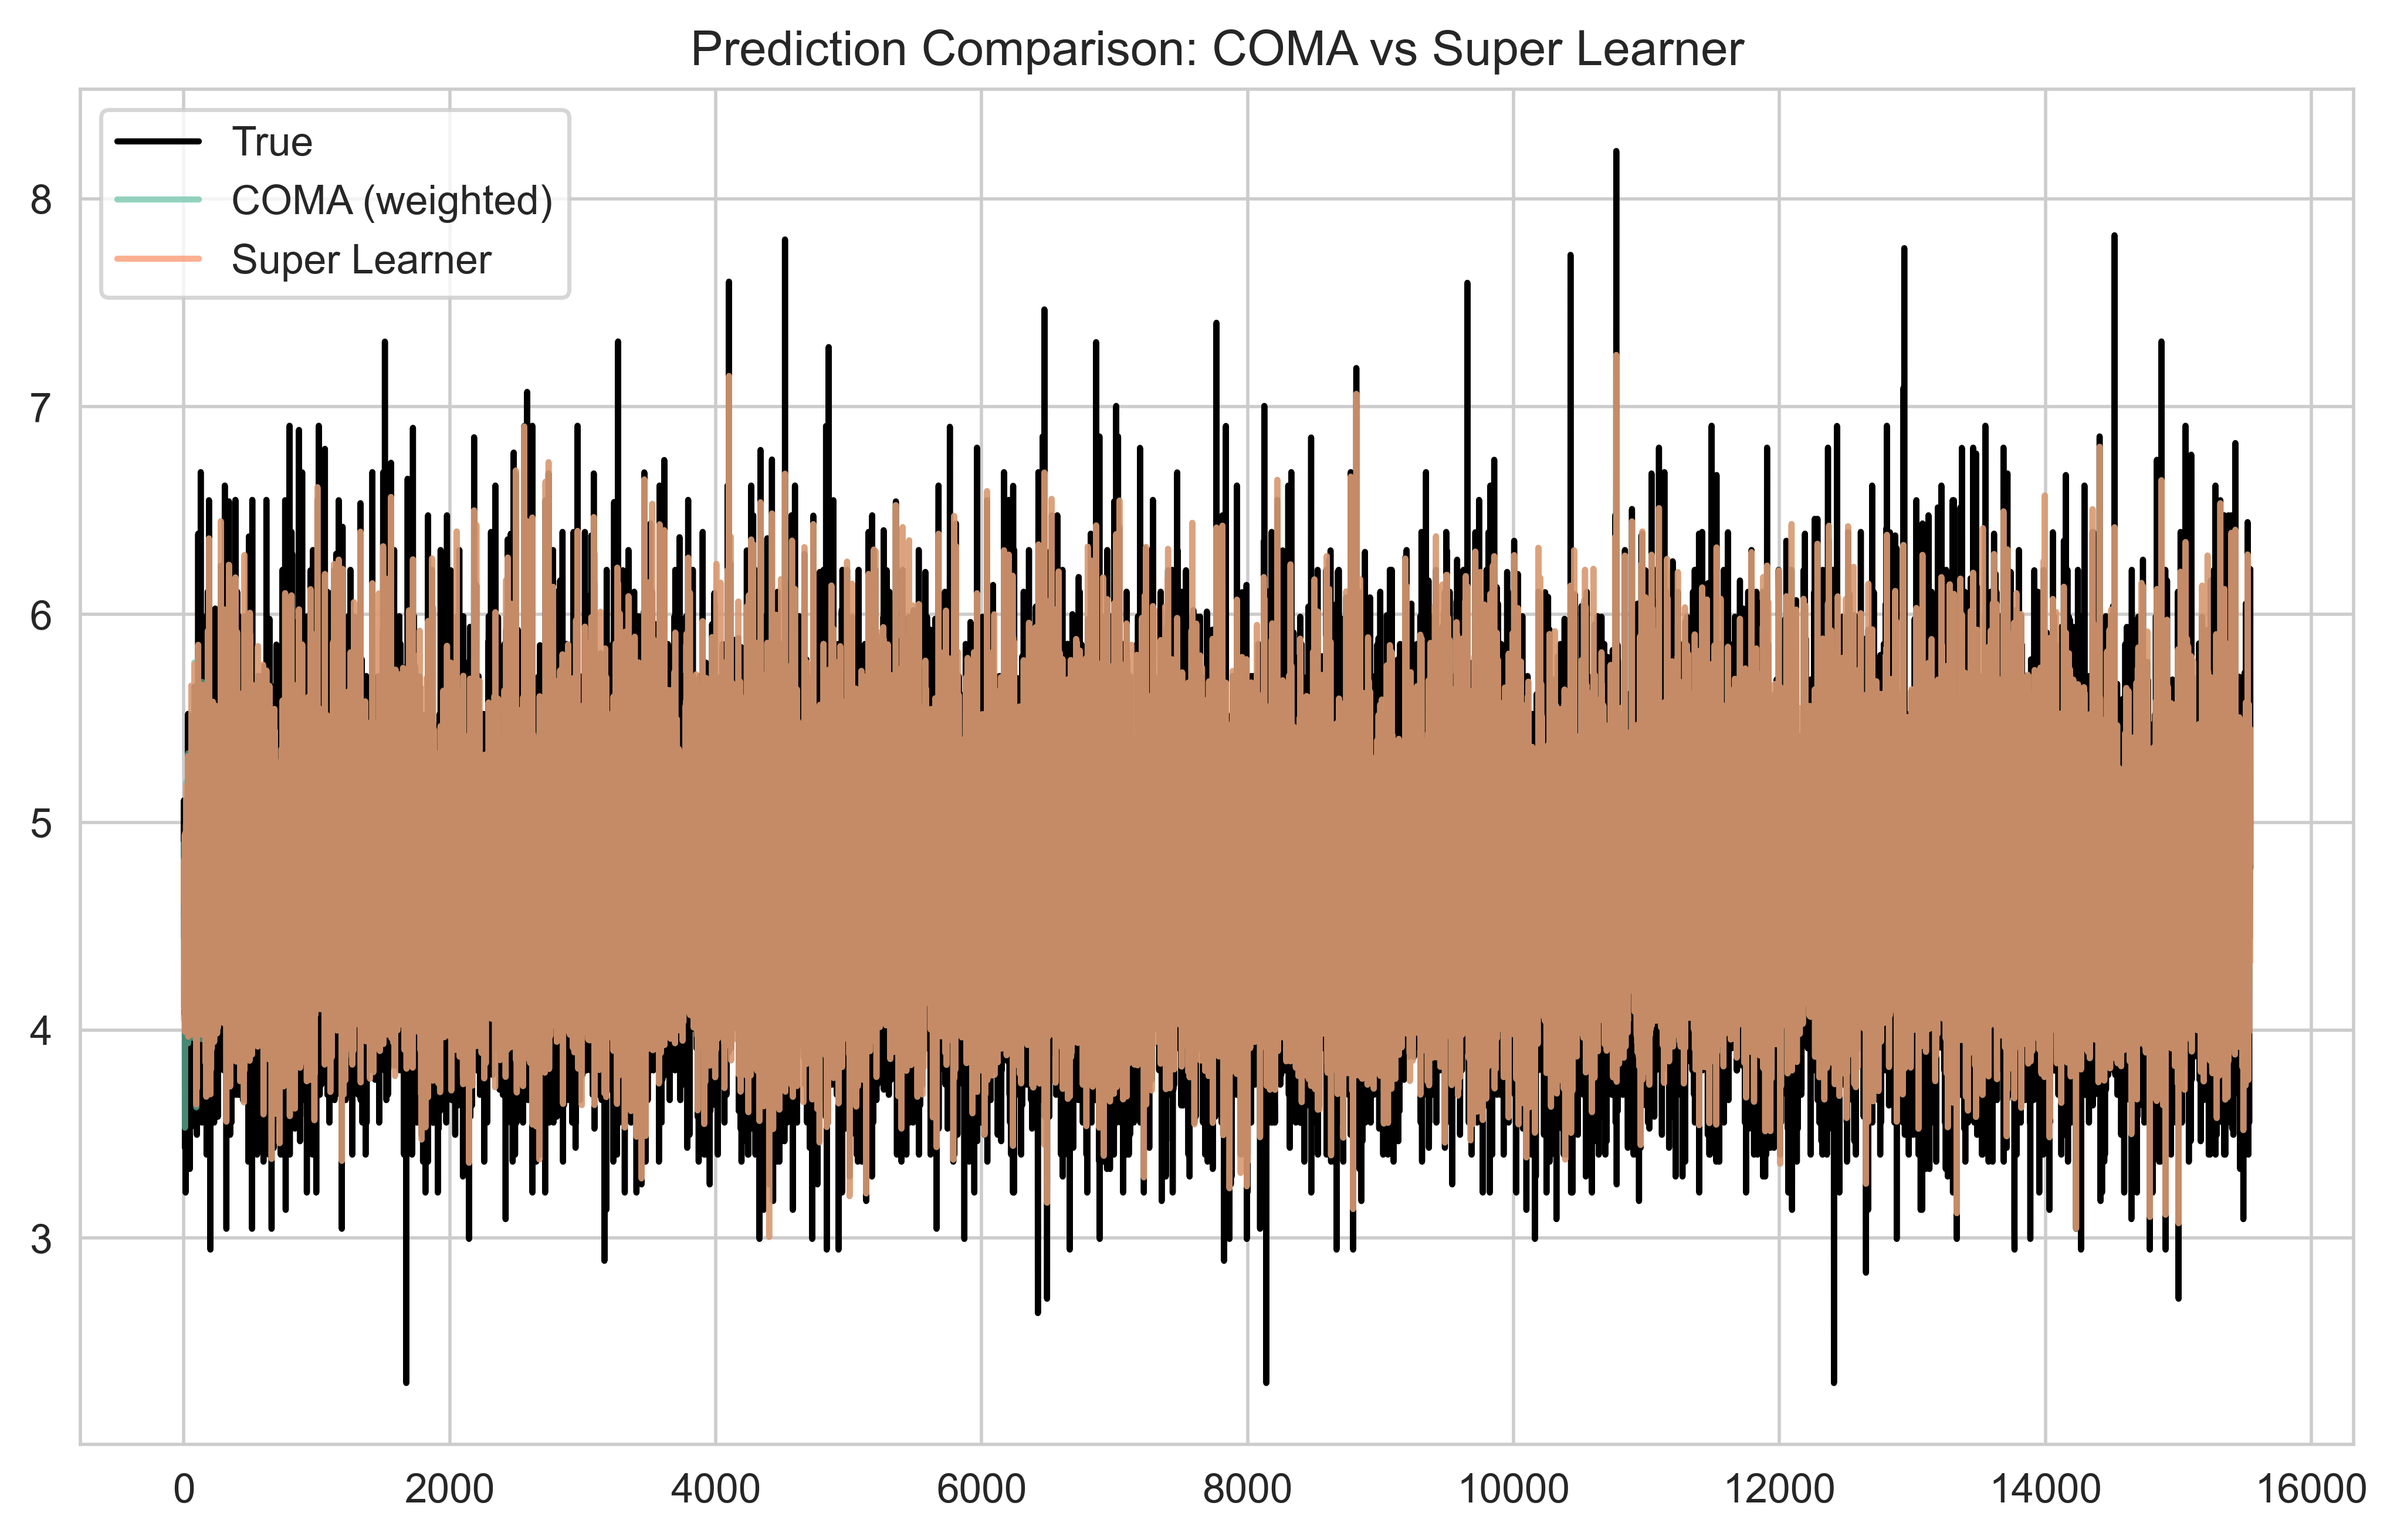

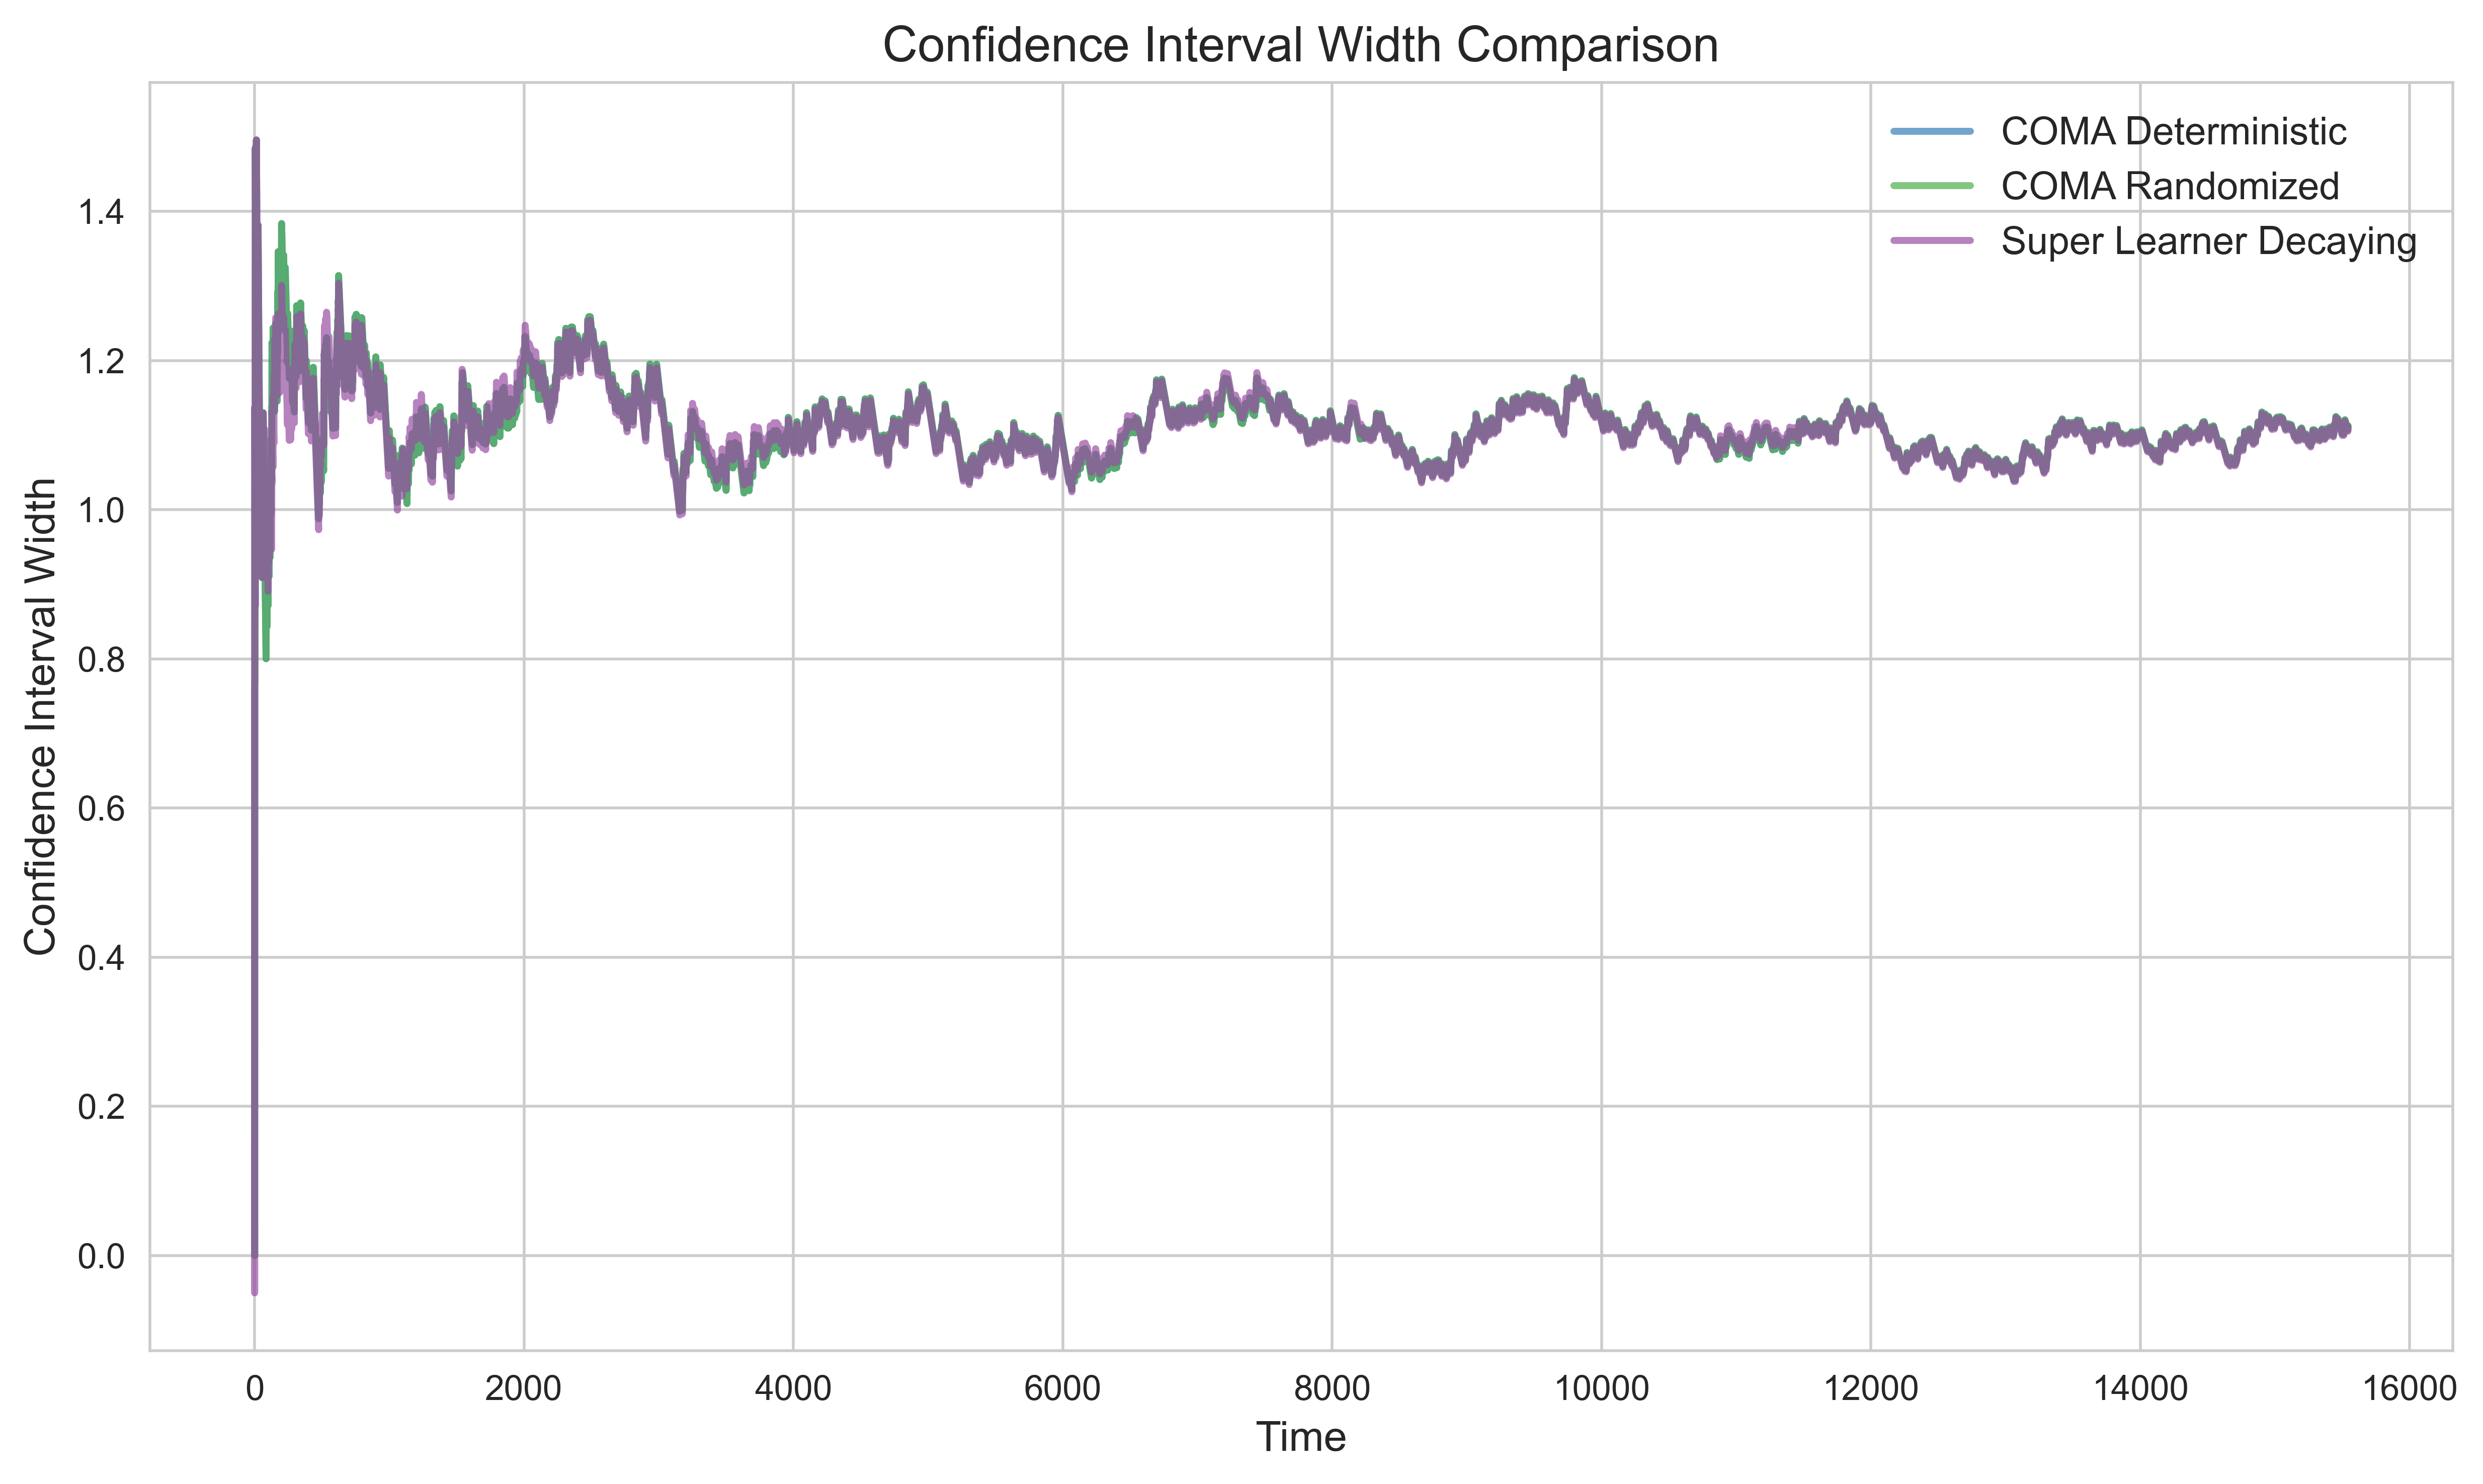

In [21]:
colors = sns.color_palette("Set1", 6)
min_len = min(
    len(rf_results['q_decaying']),
    len(lm_results['q_decaying']),
    len(lasso_results['q_decaying']),
    len(ridge_results['q_decaying']),
    len(nnet_results['q_decaying']),
    len(sl_results['q_decaying']),
    len(y_true)
)

ci_matrix = np.column_stack([
    CI_rf_decaying[-min_len:],
    CI_lm_decaying[-min_len:],
    CI_lasso_decaying[-min_len:],
    CI_ridge_decaying[-min_len:],
    CI_nnet_decaying[-min_len:]
])
adahedAlg = adahedge(loss_matrix=ci_matrix)

intervals_rf = np.column_stack([
    y_pred_rf[-min_len:] - rf_results['q_decaying'][-min_len:],
    y_pred_rf[-min_len:] + rf_results['q_decaying'][-min_len:]
])

intervals_lm = np.column_stack([
    y_pred_lm[-min_len:] - lm_results['q_decaying'][-min_len:],
    y_pred_lm[-min_len:] + lm_results['q_decaying'][-min_len:]
])

intervals_lasso = np.column_stack([
    y_pred_lasso[-min_len:] - lasso_results['q_decaying'][-min_len:],
    y_pred_lasso[-min_len:] + lasso_results['q_decaying'][-min_len:]
])

intervals_ridge = np.column_stack([
    y_pred_ridge[-min_len:] - ridge_results['q_decaying'][-min_len:],
    y_pred_ridge[-min_len:] + ridge_results['q_decaying'][-min_len:]
])

intervals_nnet = np.column_stack([
    y_pred_nnet[-min_len:] - nnet_results['q_decaying'][-min_len:],
    y_pred_nnet[-min_len:] + nnet_results['q_decaying'][-min_len:]
])

intervals_list_plain = [intervals_rf, intervals_lm, intervals_lasso, intervals_ridge, intervals_nnet]
weights_plain = adahedAlg["weights"]

y_test_aligned = y_true[-min_len:]
result_plain = coma_loop(intervals_list_plain, weights_plain, y_test_aligned)

print("Mean deterministic coverage:", result_plain["mean_m_cov"])
print("Mean randomized coverage:", result_plain["mean_wm_cov"])

pi_m   = result_plain["pi_m"]
pi_wm  = result_plain["pi_wm"]

coma_width_det  = np.array([loss_fun(ci) for ci in pi_m])
coma_width_rand = np.array([loss_fun(ci) for ci in pi_wm])

CI_super_decaying = CI_sl_decaying[-min_len:]

print("Mean CI width — COMA (det):", np.nanmean(coma_width_det))
print("Mean CI width — COMA (rand):", np.nanmean(coma_width_rand))
print("Mean CI width — Super Learner:", np.mean(CI_super_decaying))

base_preds_matrix = np.column_stack([
    y_pred_rf[-min_len:],
    y_pred_lm[-min_len:],
    y_pred_lasso[-min_len:],
    y_pred_ridge[-min_len:],
    y_pred_nnet[-min_len:]
])

coma_preds_weighted = np.sum(base_preds_matrix * weights_plain, axis=1)

plt.figure(figsize=(10, 6), dpi=500)
plt.plot(y_test_aligned, label="True", color="black")
plt.plot(coma_preds_weighted, label="COMA (weighted)", alpha=0.7)
plt.plot(super_preds[-min_len:], label="Super Learner", alpha=0.7)
plt.legend()
plt.title("Prediction Comparison: COMA vs Super Learner")
plt.show()

plt.figure(figsize=(10, 6), dpi=500)

plt.plot(coma_width_det, label='COMA Deterministic', linewidth=2, alpha = 0.7, color=colors[1])
plt.plot(coma_width_rand, label='COMA Randomized', linewidth=2, alpha = 0.7, color=colors[2])
plt.plot(CI_super_decaying, label='Super Learner Decaying', linewidth=2, alpha = 0.7, color=colors[3])

plt.xlabel('Time', fontsize=12)
plt.ylabel('Confidence Interval Width', fontsize=12)
plt.title('Confidence Interval Width Comparison', fontsize=14)

plt.legend(frameon=False, fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()


#### smooth

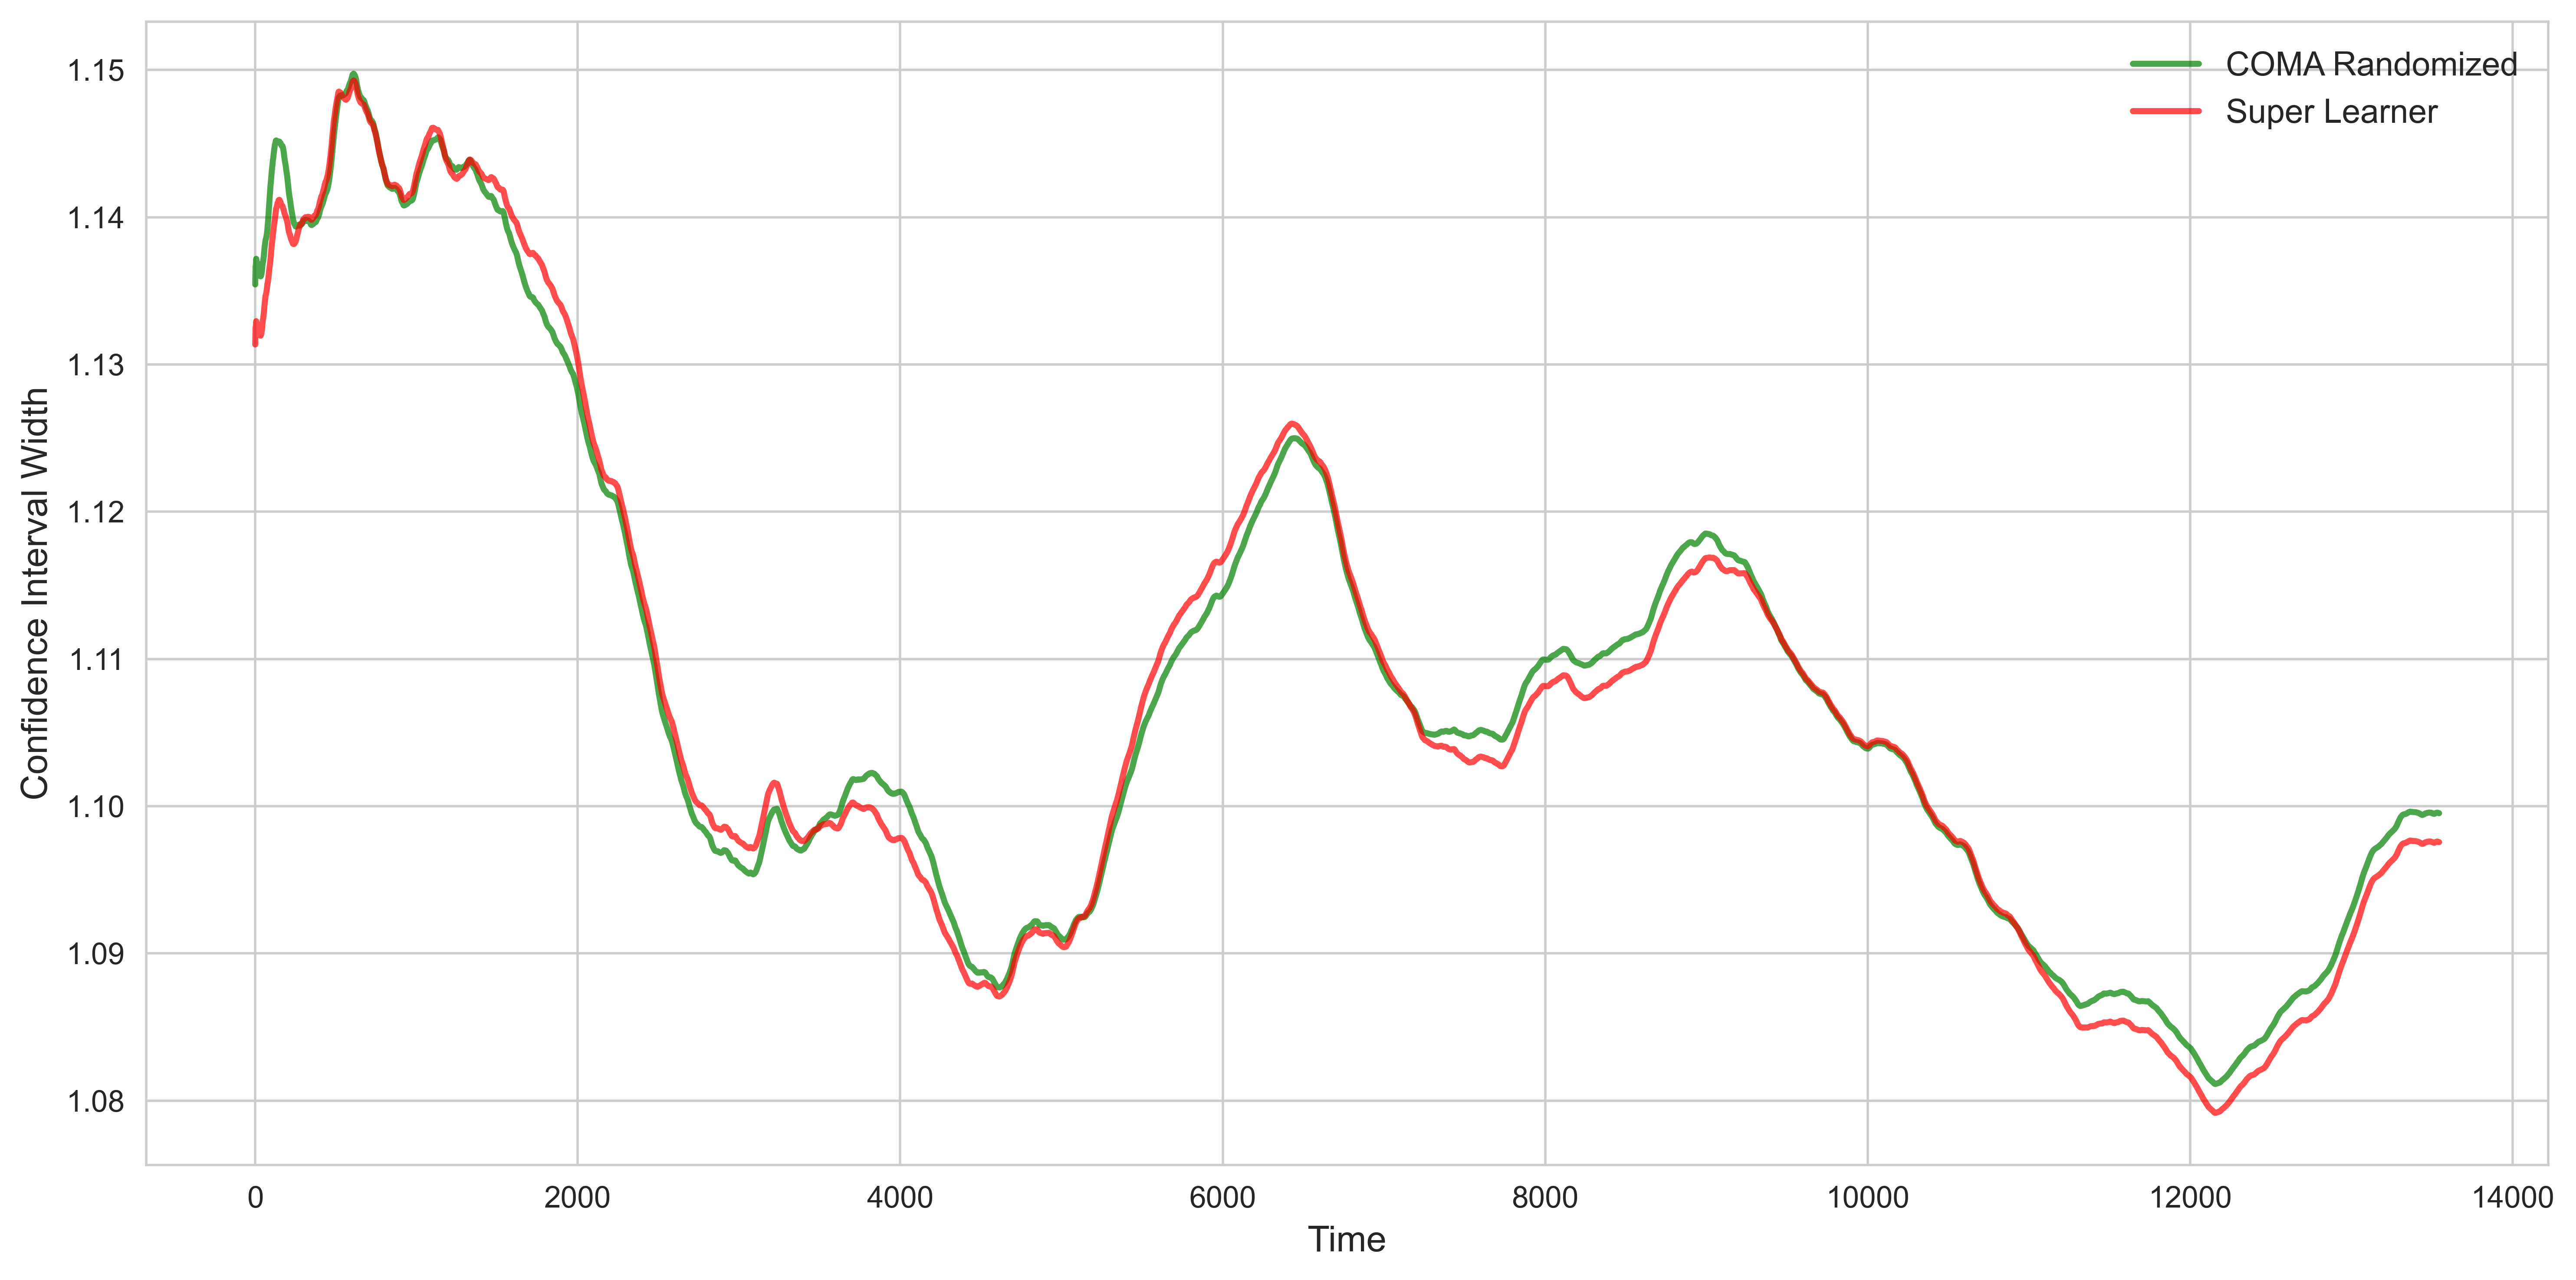

In [22]:

coma_width_det_smooth     = smooth_series(coma_width_det, window=2000)
coma_width_rand_smooth    = smooth_series(coma_width_rand, window=2000)
sl_smooth = smooth_series(CI_super_decaying, window=2000)   

plt.figure(figsize=(12, 6), dpi=500)
plt.plot(coma_width_rand_smooth, label='COMA Randomized', linewidth=2, alpha = 0.7, color='green')
plt.plot(sl_smooth, label='Super Learner', linewidth=2, alpha = 0.7, color='red')

plt.xlabel('Time', fontsize=12)
plt.ylabel('Confidence Interval Width', fontsize=12)
#plt.title("Airbnb (i.i.d, Adahedge, Smoothed): CI Widths — COMA(base) vs Super Learner", fontsize=14)

plt.legend(frameon=False, fontsize=11, loc='upper right')
plt.tight_layout()
plt.savefig("iid_adahedge_smooth_line_base.png", dpi=500, bbox_inches="tight")
plt.show()


### coma v.s. coma +sl 

Mean deterministic coverage: 0.8998262883613202
Mean randomized coverage: 0.8998262883613202
Mean CI width — COMA (rand): 1.1097731157553254
Mean CI width — COMA (rand) + SL: 1.108589678446376


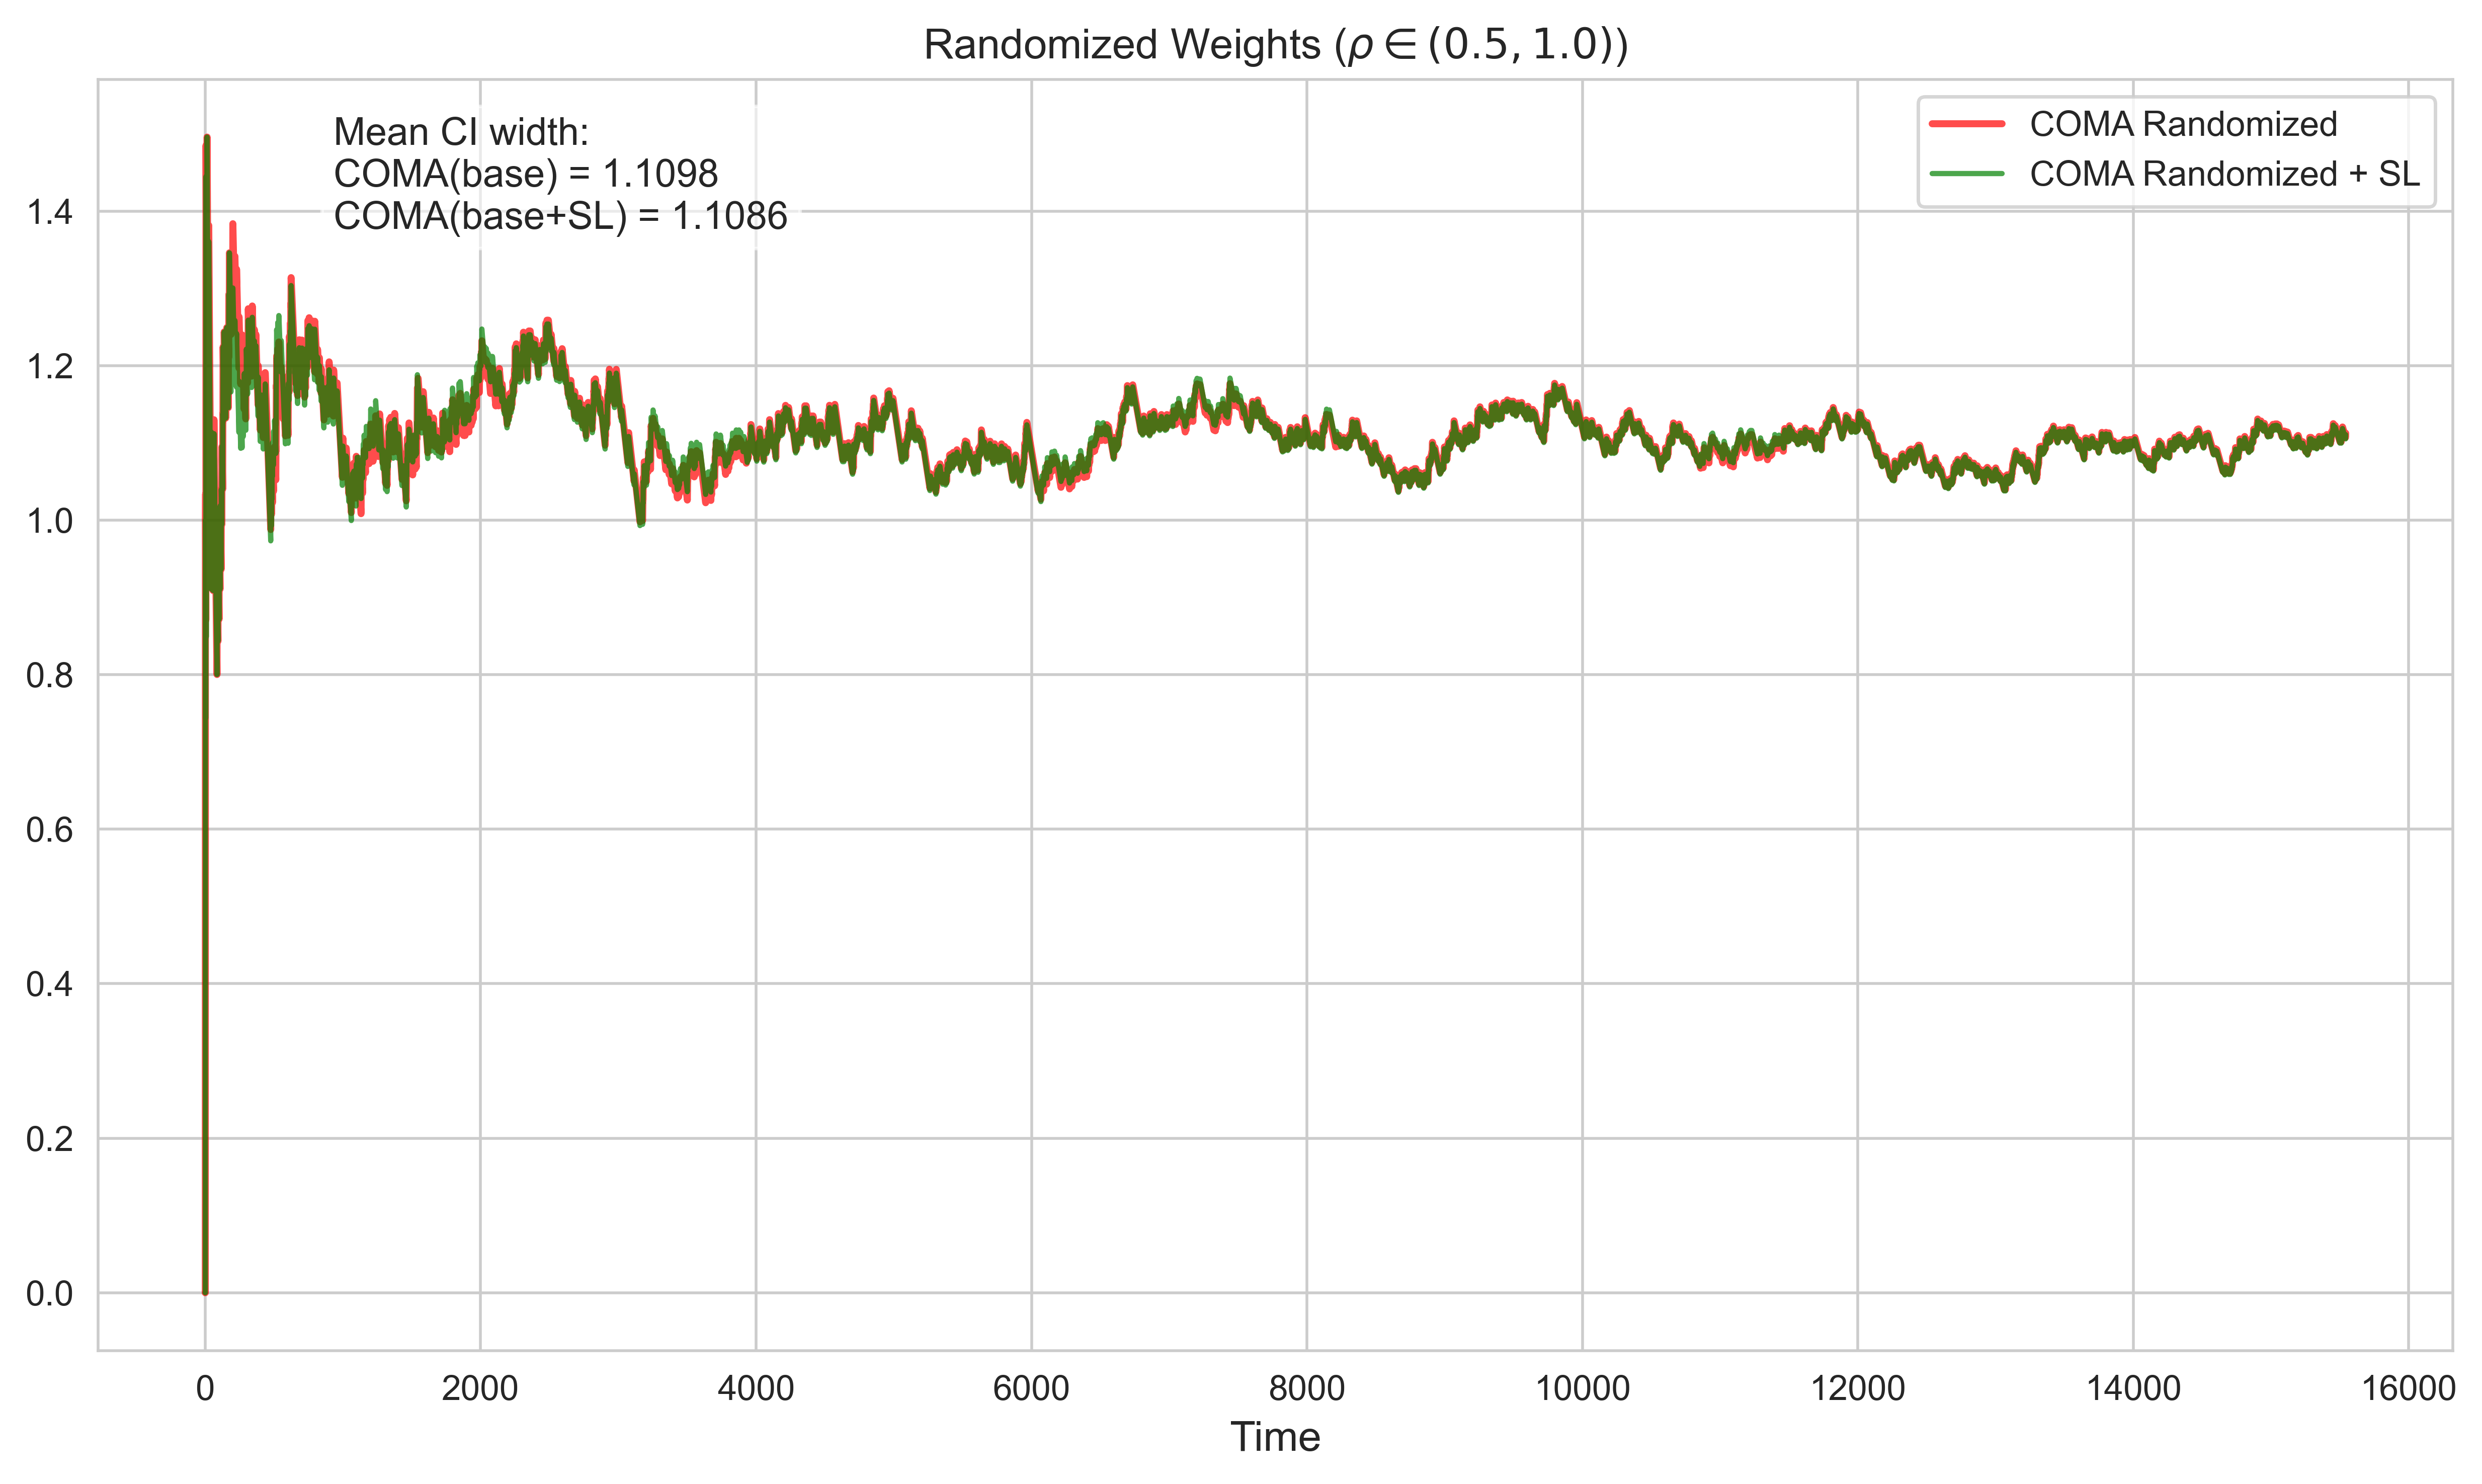

In [14]:

min_len = min(
    len(rf_results['q_decaying']),
    len(lm_results['q_decaying']),
    len(lasso_results['q_decaying']),
    len(ridge_results['q_decaying']),
    len(nnet_results['q_decaying']),
    len(sl_results['q_decaying']),
    len(y_true)
)

ci_matrix_sl = np.column_stack([
    CI_rf_decaying[-min_len:],
    CI_lm_decaying[-min_len:],
    CI_lasso_decaying[-min_len:],
    CI_ridge_decaying[-min_len:],
    CI_nnet_decaying[-min_len:],
    CI_sl_decaying[-min_len:]
])

adahedAlg_sl = adahedge(loss_matrix=ci_matrix_sl)


intervals_sp = np.column_stack([
    super_preds[-min_len:] - sl_results['q_decaying'][-min_len:],
    super_preds[-min_len:] + sl_results['q_decaying'][-min_len:]
])

intervals_list_sl = [intervals_rf, intervals_lm, intervals_lasso, intervals_ridge, intervals_nnet, intervals_sp]
weights_sl = adahedAlg_sl["weights"]

y_test_aligned = y_true[-min_len:]

result_sl = coma_loop(intervals_list_sl, weights_sl, y_test_aligned)

print("Mean deterministic coverage:", result_sl["mean_m_cov"])
print("Mean randomized coverage:", result_sl["mean_wm_cov"])


pi_wm_sl  = result_sl["pi_wm"]

coma_width_rand_sl = np.array([loss_fun(ci) for ci in pi_wm_sl])
print("Mean CI width — COMA (rand):", np.nanmean(coma_width_rand))
print("Mean CI width — COMA (rand) + SL:", np.nanmean(coma_width_rand_sl))

plt.figure(figsize=(10, 6), dpi=500)


# Randomized subplot 
plt.plot(coma_width_rand, label='COMA Randomized', linewidth=2, alpha=0.7, color='red')
plt.plot(coma_width_rand_sl, label='COMA Randomized + SL', linewidth=1.5, alpha=0.7, color='green')
plt.title("Randomized Weights ($\\rho \\in (0.5,1.0)$)", fontsize=12)
plt.xlabel("Time", fontsize=12)
plt.legend()

# Add mean values annotation
mean_rand = np.nanmean(coma_width_rand)
mean_rand_sl = np.nanmean(coma_width_rand_sl)
plt.text(0.1, 0.97,
         f"Mean CI width:\nCOMA(base) = {mean_rand:.4f}\nCOMA(base+SL) = {mean_rand_sl:.4f}",
         transform=plt.gca().transAxes,
         fontsize=11, verticalalignment="top",
         bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

#plt.suptitle("Airbnb(i.i.d, Adahedge): Confidence Interval Widths: COMA(base) vs COMA(base+Super Learner)", fontsize=14)
plt.tight_layout()
plt.savefig("iid_adahedge_line_coma.png", dpi=500, bbox_inches="tight")
plt.show()

#### boxplot

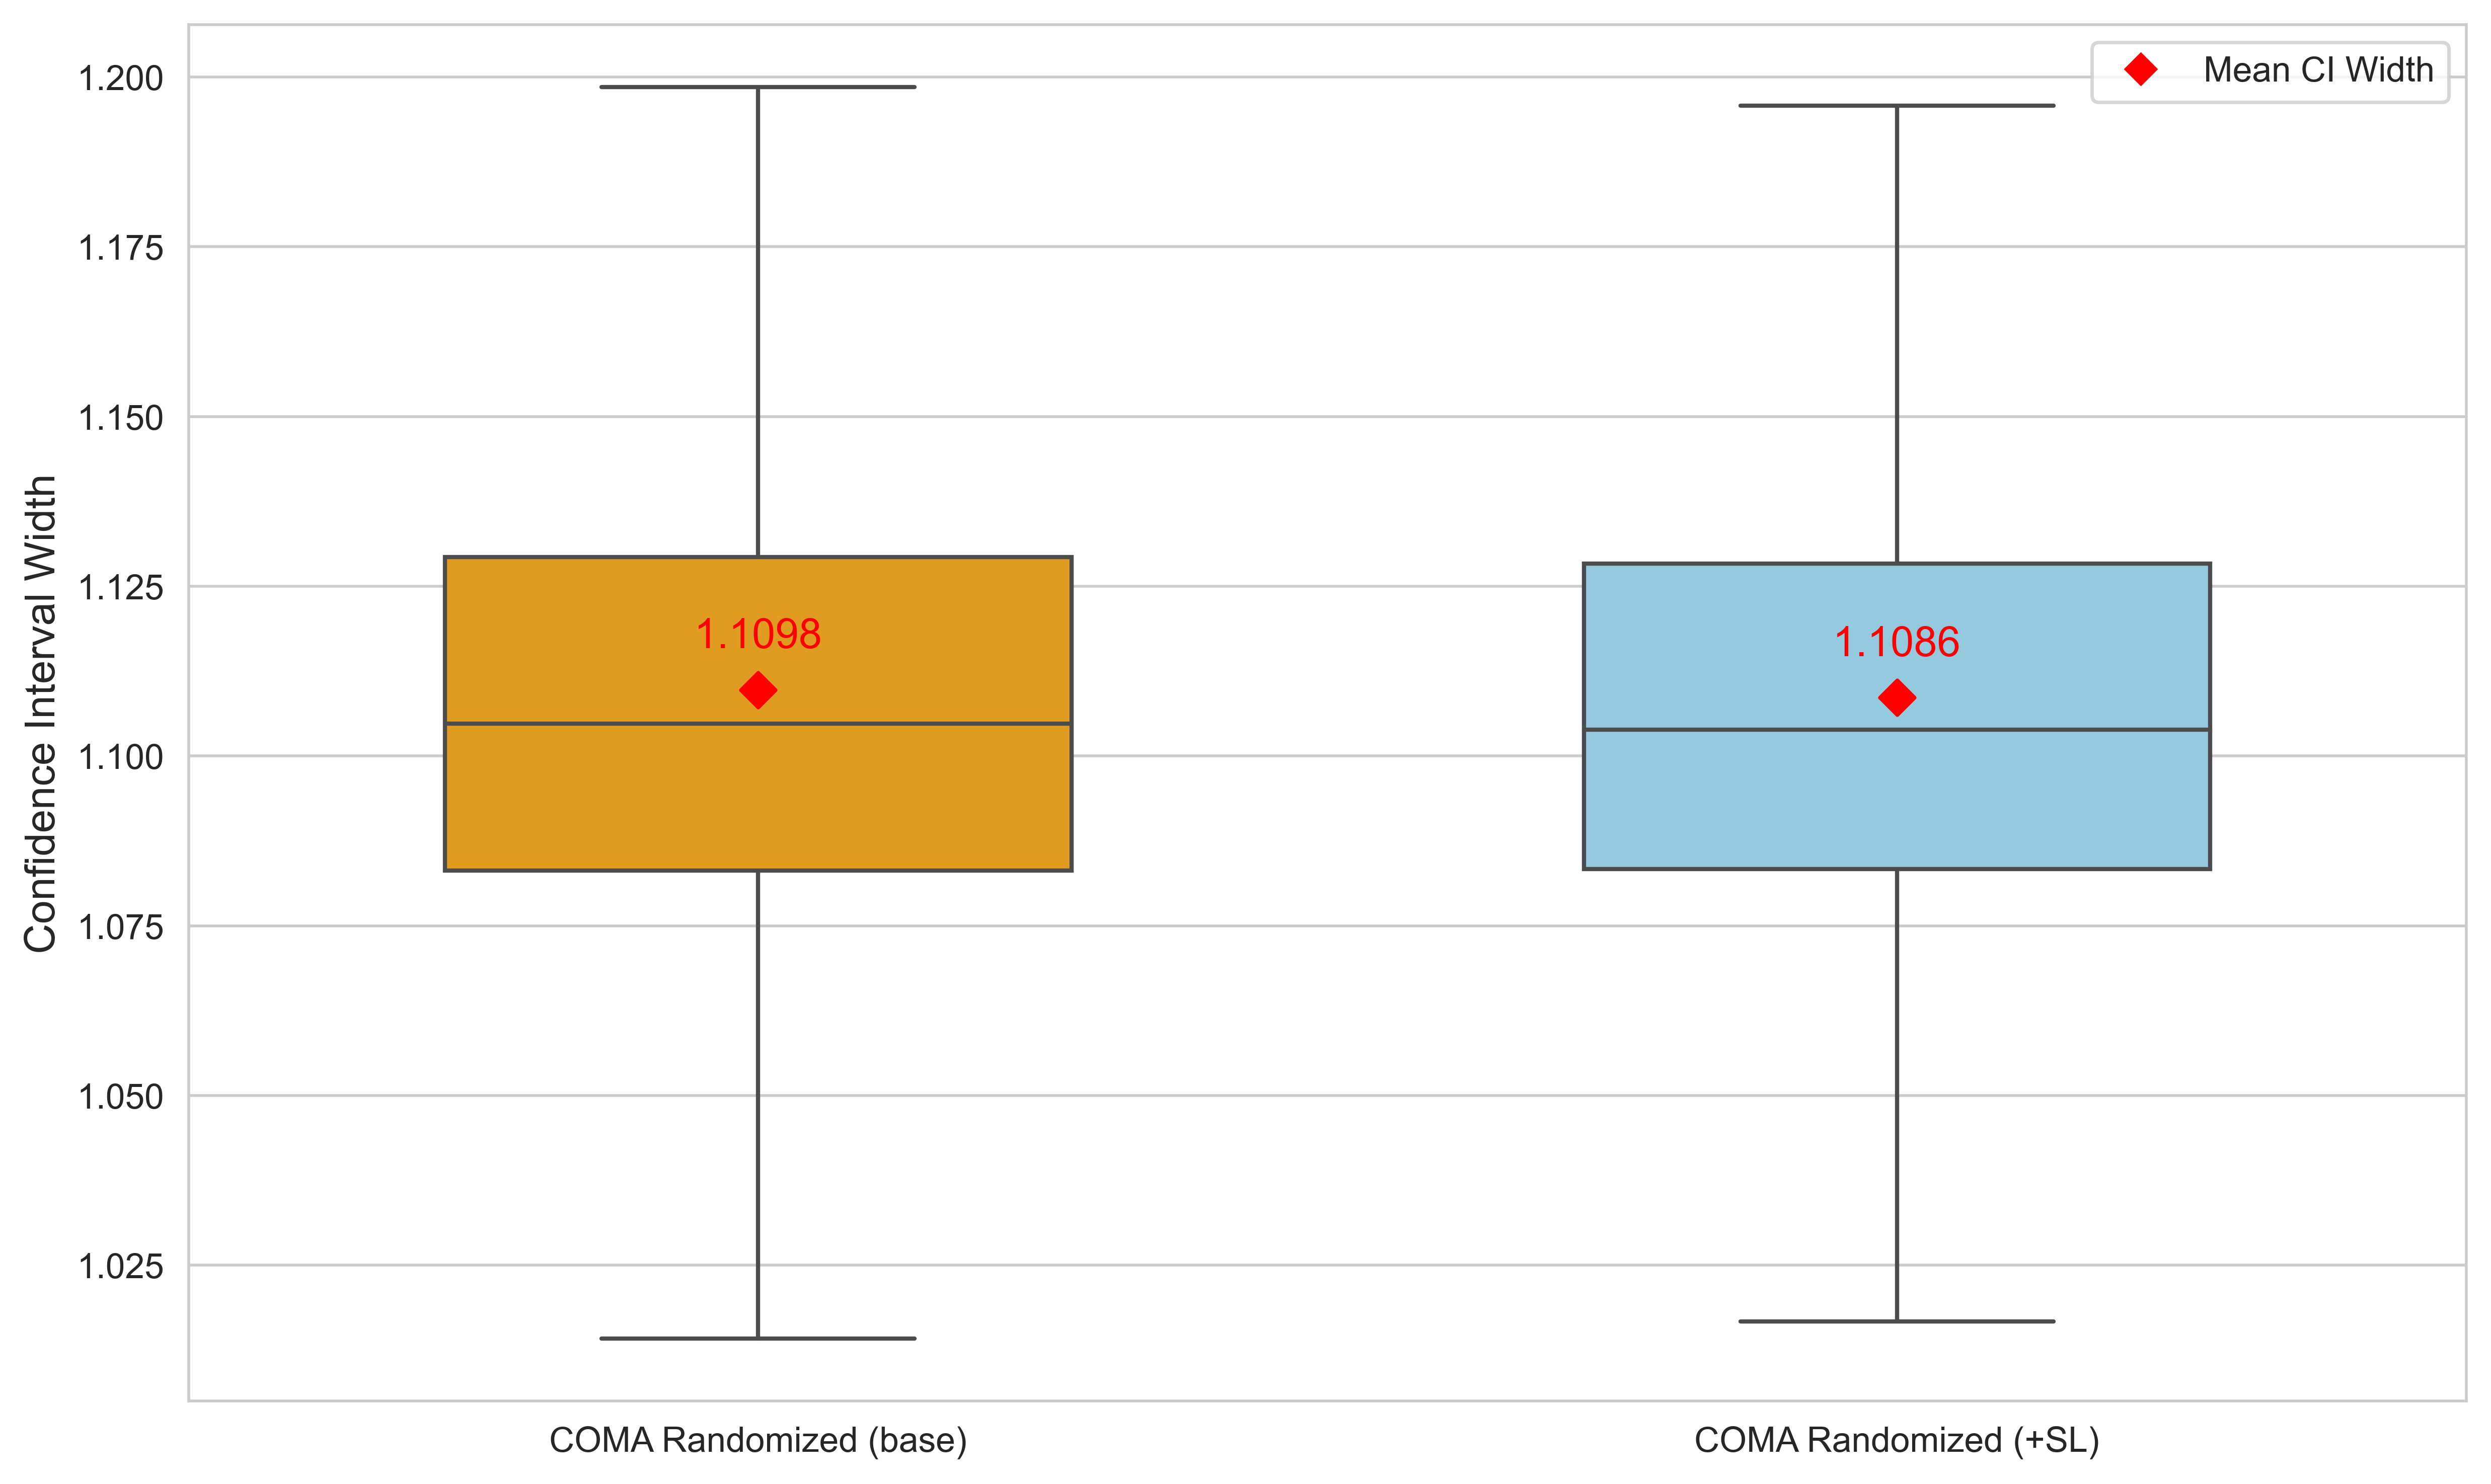

In [15]:
data_dict = {
    "COMA Randomized (base)": coma_width_rand,
    "COMA Randomized (+SL)": coma_width_rand_sl
}

df_box = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data_dict.items()]))
df_long = df_box.melt(var_name="Method", value_name="CI Width")
rand_methods = ["COMA Randomized (base)", "COMA Randomized (+SL)"]

palette = {"COMA Randomized (base)": "orange",
           "COMA Randomized (+SL)": "skyblue"}

plt.figure(figsize=(10, 6), dpi=500)

# Boxplot (randomized methods only)
sns.boxplot(
    x="Method",
    y="CI Width",
    data=df_long[df_long["Method"].isin(rand_methods)],
    order=rand_methods,
    palette=palette,
    showfliers=False,
    width=0.55,
    linewidth=1.2
)

# Mean CI width (red diamonds)
means_rand = [np.nanmean(data_dict[m]) for m in rand_methods]
for i, m in enumerate(rand_methods):
    plt.scatter(i, means_rand[i], color="red", marker="D", s=50, zorder=3)
    plt.text(
        i,
        means_rand[i] + 0.005,
        f"{means_rand[i]:.4f}",
        ha="center",
        va="bottom",
        fontsize=12,
        color="red"
    )

plt.xlabel("")
plt.ylabel("Confidence Interval Width", fontsize=12)
plt.legend(
    handles=[plt.Line2D([0], [0], color="red", marker="D",
                        linestyle="", label="Mean CI Width")],
    loc="upper right"
)

#plt.suptitle("Airbnb(i.i.d, Adahedge): Boxplot of CI Widths — COMA(base) vs COMA+Super Learner", fontsize=14)
plt.tight_layout()
plt.savefig("iid_adahedge_boxplot_comasl.png", dpi=500, bbox_inches="tight")
plt.show()

#### smooth

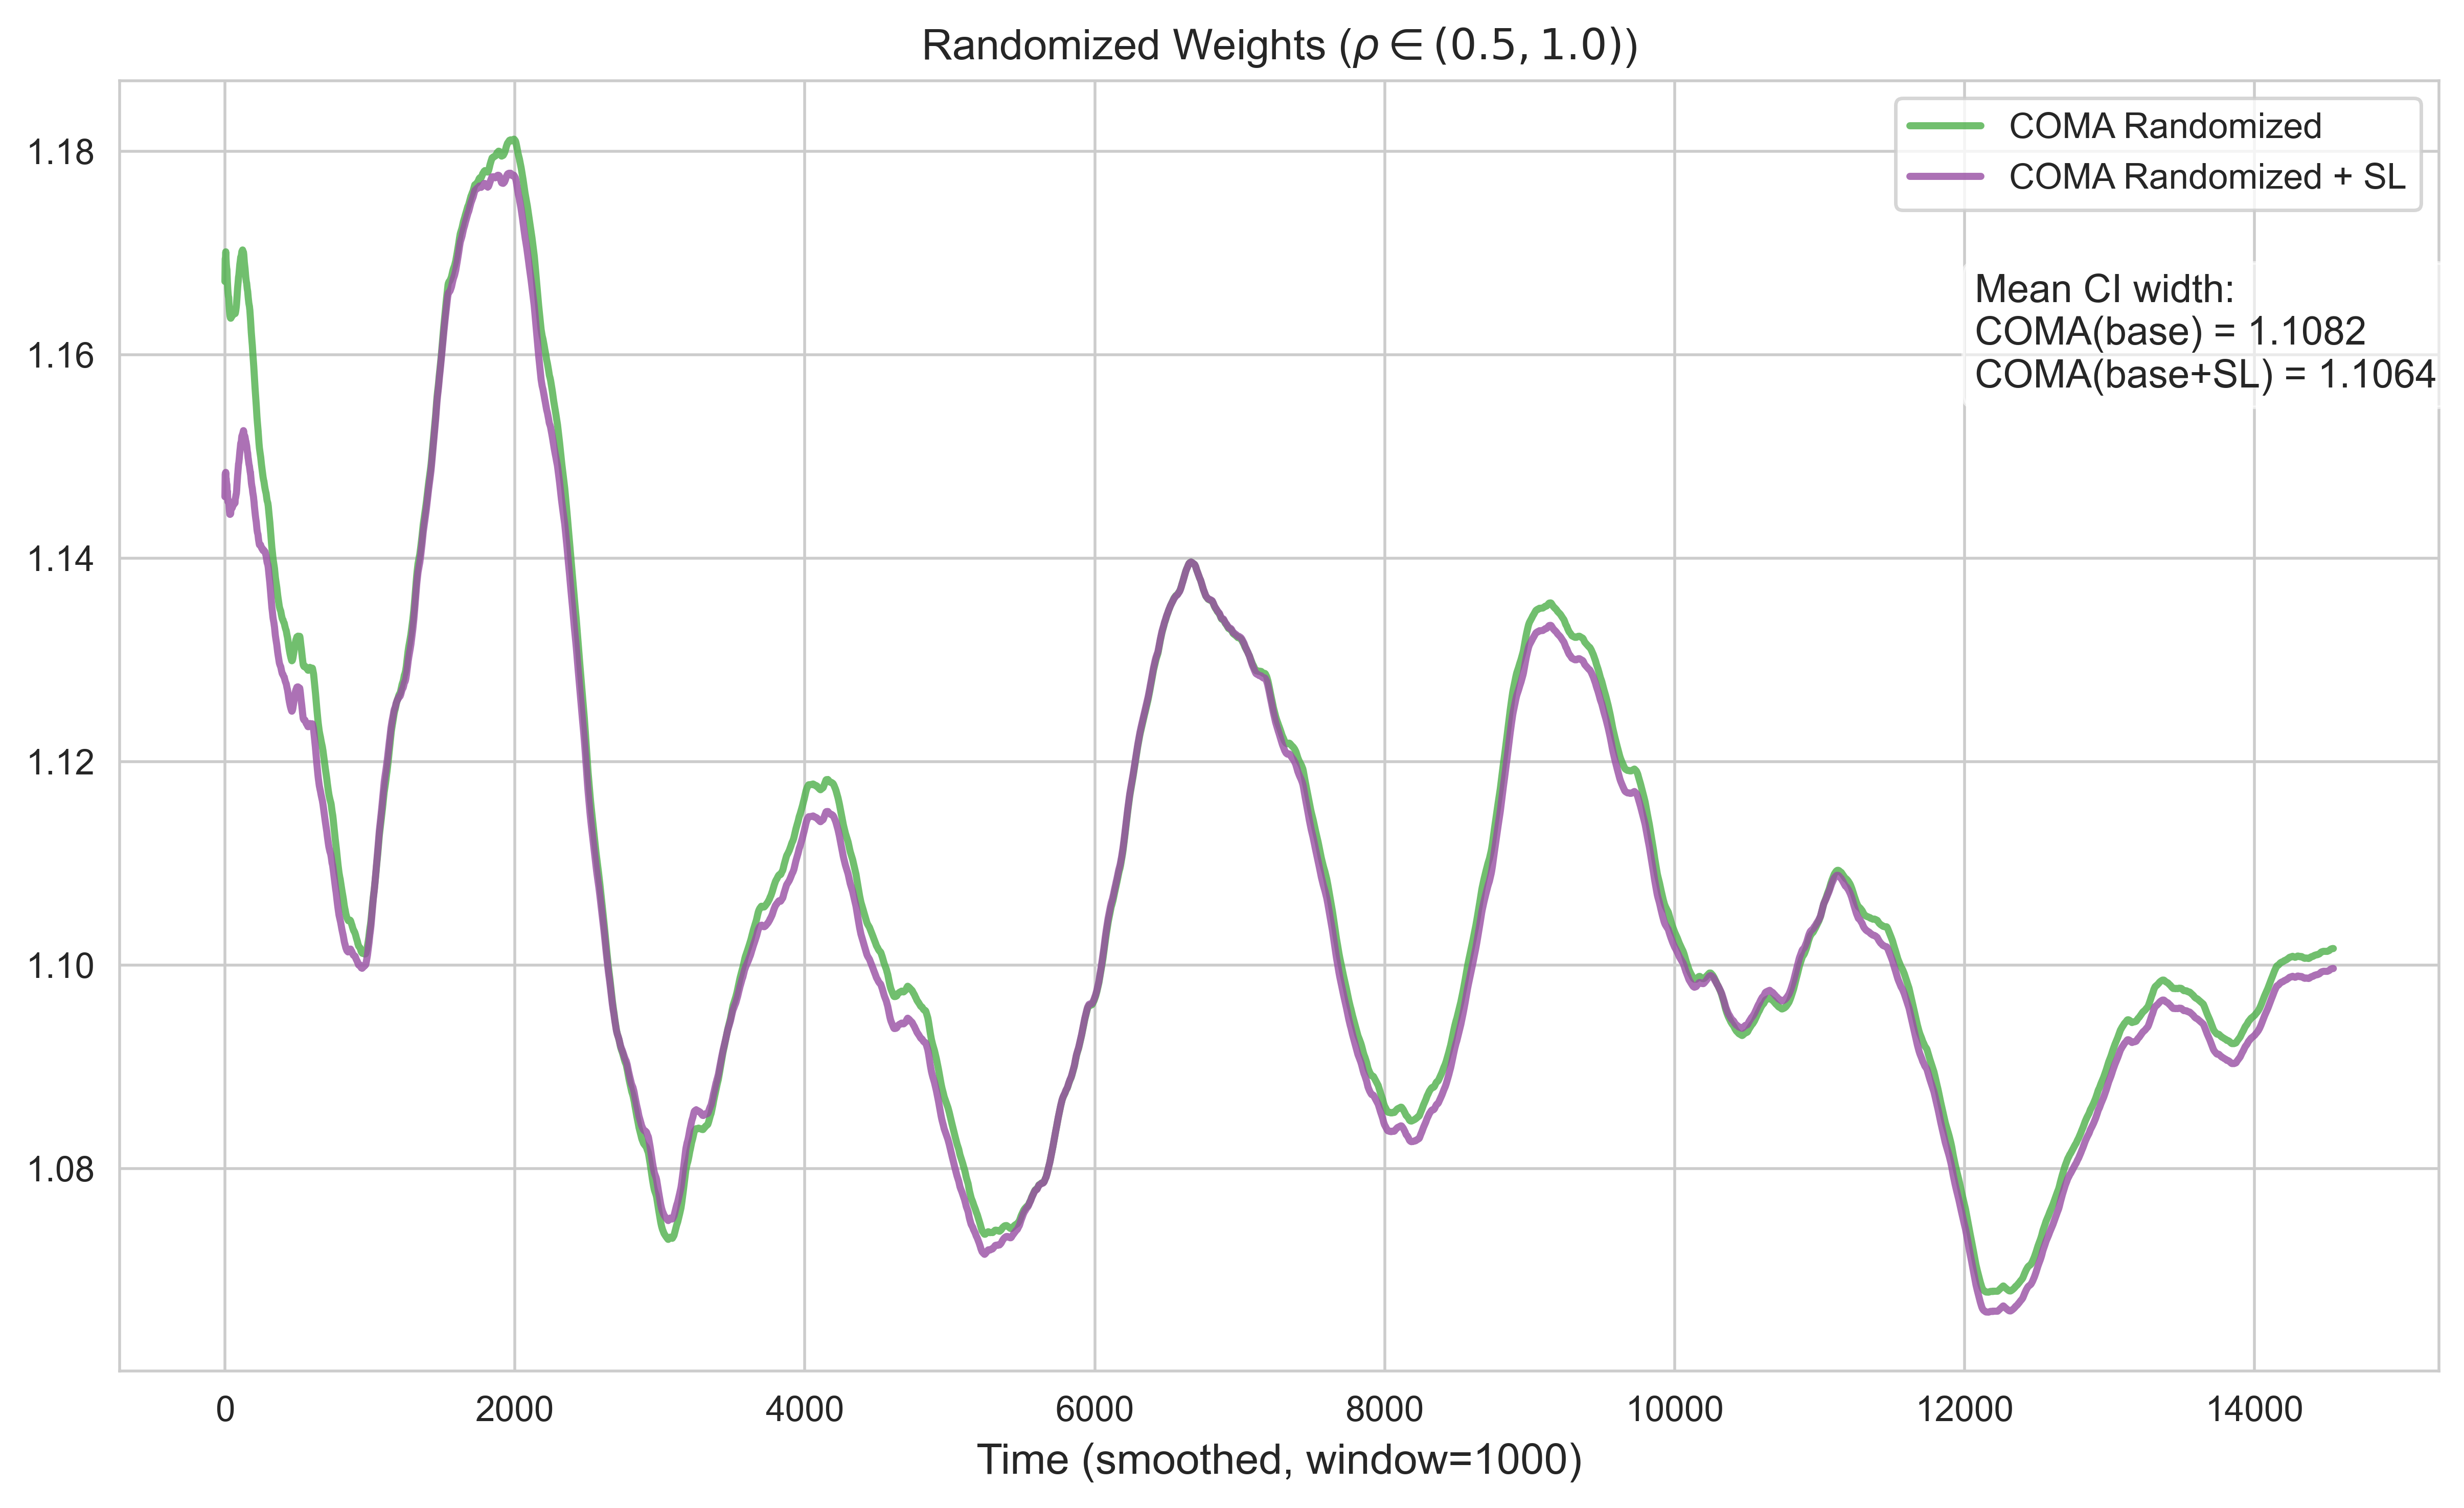

In [26]:

#coma_width_det_smooth     = smooth_series(coma_width_det, window=1000)
coma_width_rand_smooth    = smooth_series(coma_width_rand, window=1000)
#coma_width_det_sl_smooth  = smooth_series(coma_width_det_sl, window=1000)
coma_width_rand_sl_smooth = smooth_series(coma_width_rand_sl, window=1000)

# Randomized subplot 
plt.figure(figsize=(10, 6), dpi=500)
plt.plot(coma_width_rand_smooth, label='COMA Randomized', linewidth=2, alpha=0.8, color=colors[2])
plt.plot(coma_width_rand_sl_smooth, label='COMA Randomized + SL', linewidth=2, alpha=0.8, color=colors[3])
plt.title("Randomized Weights ($\\rho \\in (0.5,1.0)$)", fontsize=12)
plt.xlabel("Time (smoothed, window=1000)", fontsize=12)
plt.legend()
mean_rand = np.nanmean(coma_width_rand_smooth)
mean_rand_sl = np.nanmean(coma_width_rand_sl_smooth)
plt.text(0.8, 0.85,
         f"Mean CI width:\nCOMA(base) = {mean_rand:.4f}\nCOMA(base+SL) = {mean_rand_sl:.4f}",
         transform=plt.gca().transAxes,
         fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))


#plt.suptitle("Airbnb(i.i.d, Adahedge, Smoothed): CI Widths — COMA(base) vs COMA+Super Learner", fontsize=14)
plt.tight_layout()
plt.savefig("iid_adahedge_smooth_line_comasl.png", dpi=500, bbox_inches="tight")
plt.show()

## Hedge 

### coma v.s. sl 

Mean randomized coverage (COMA base): 0.8998906260052757
Mean randomized coverage (COMA+SL): 0.8993115872096764
Mean CI width — COMA(base, rand): 1.1094702708023354
Mean CI width — COMA(base+SL, rand): 1.1071194650340328


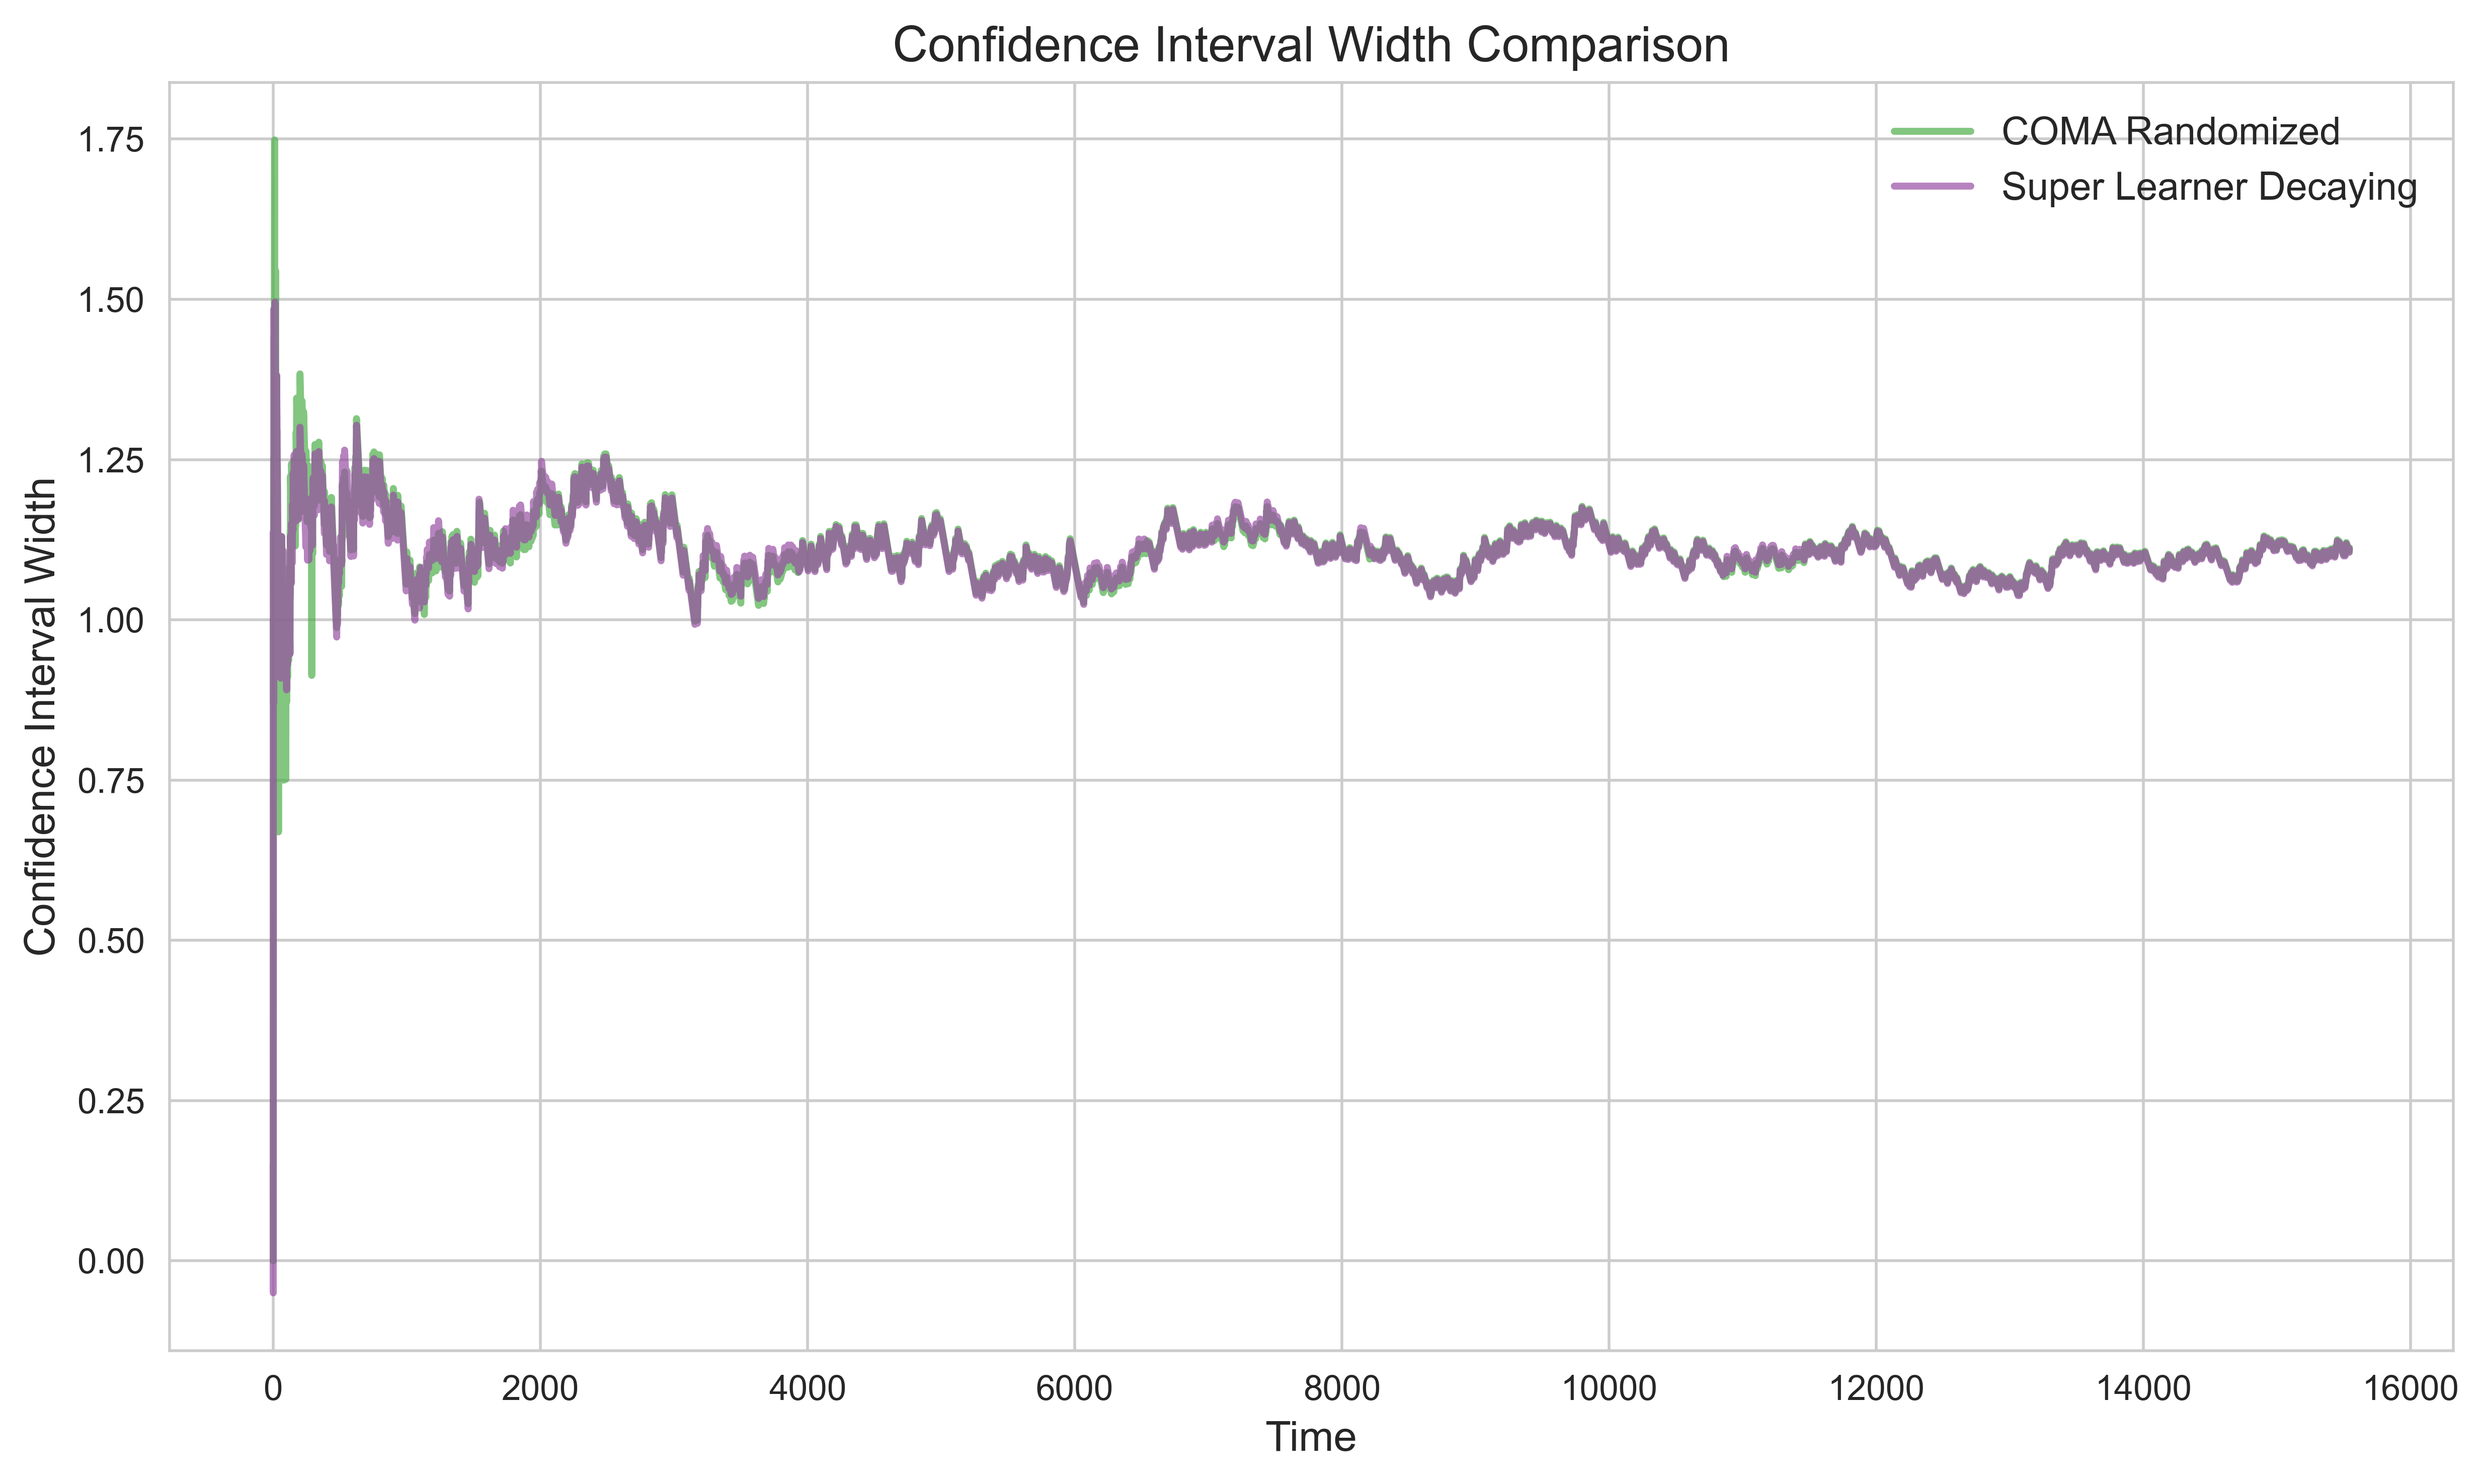

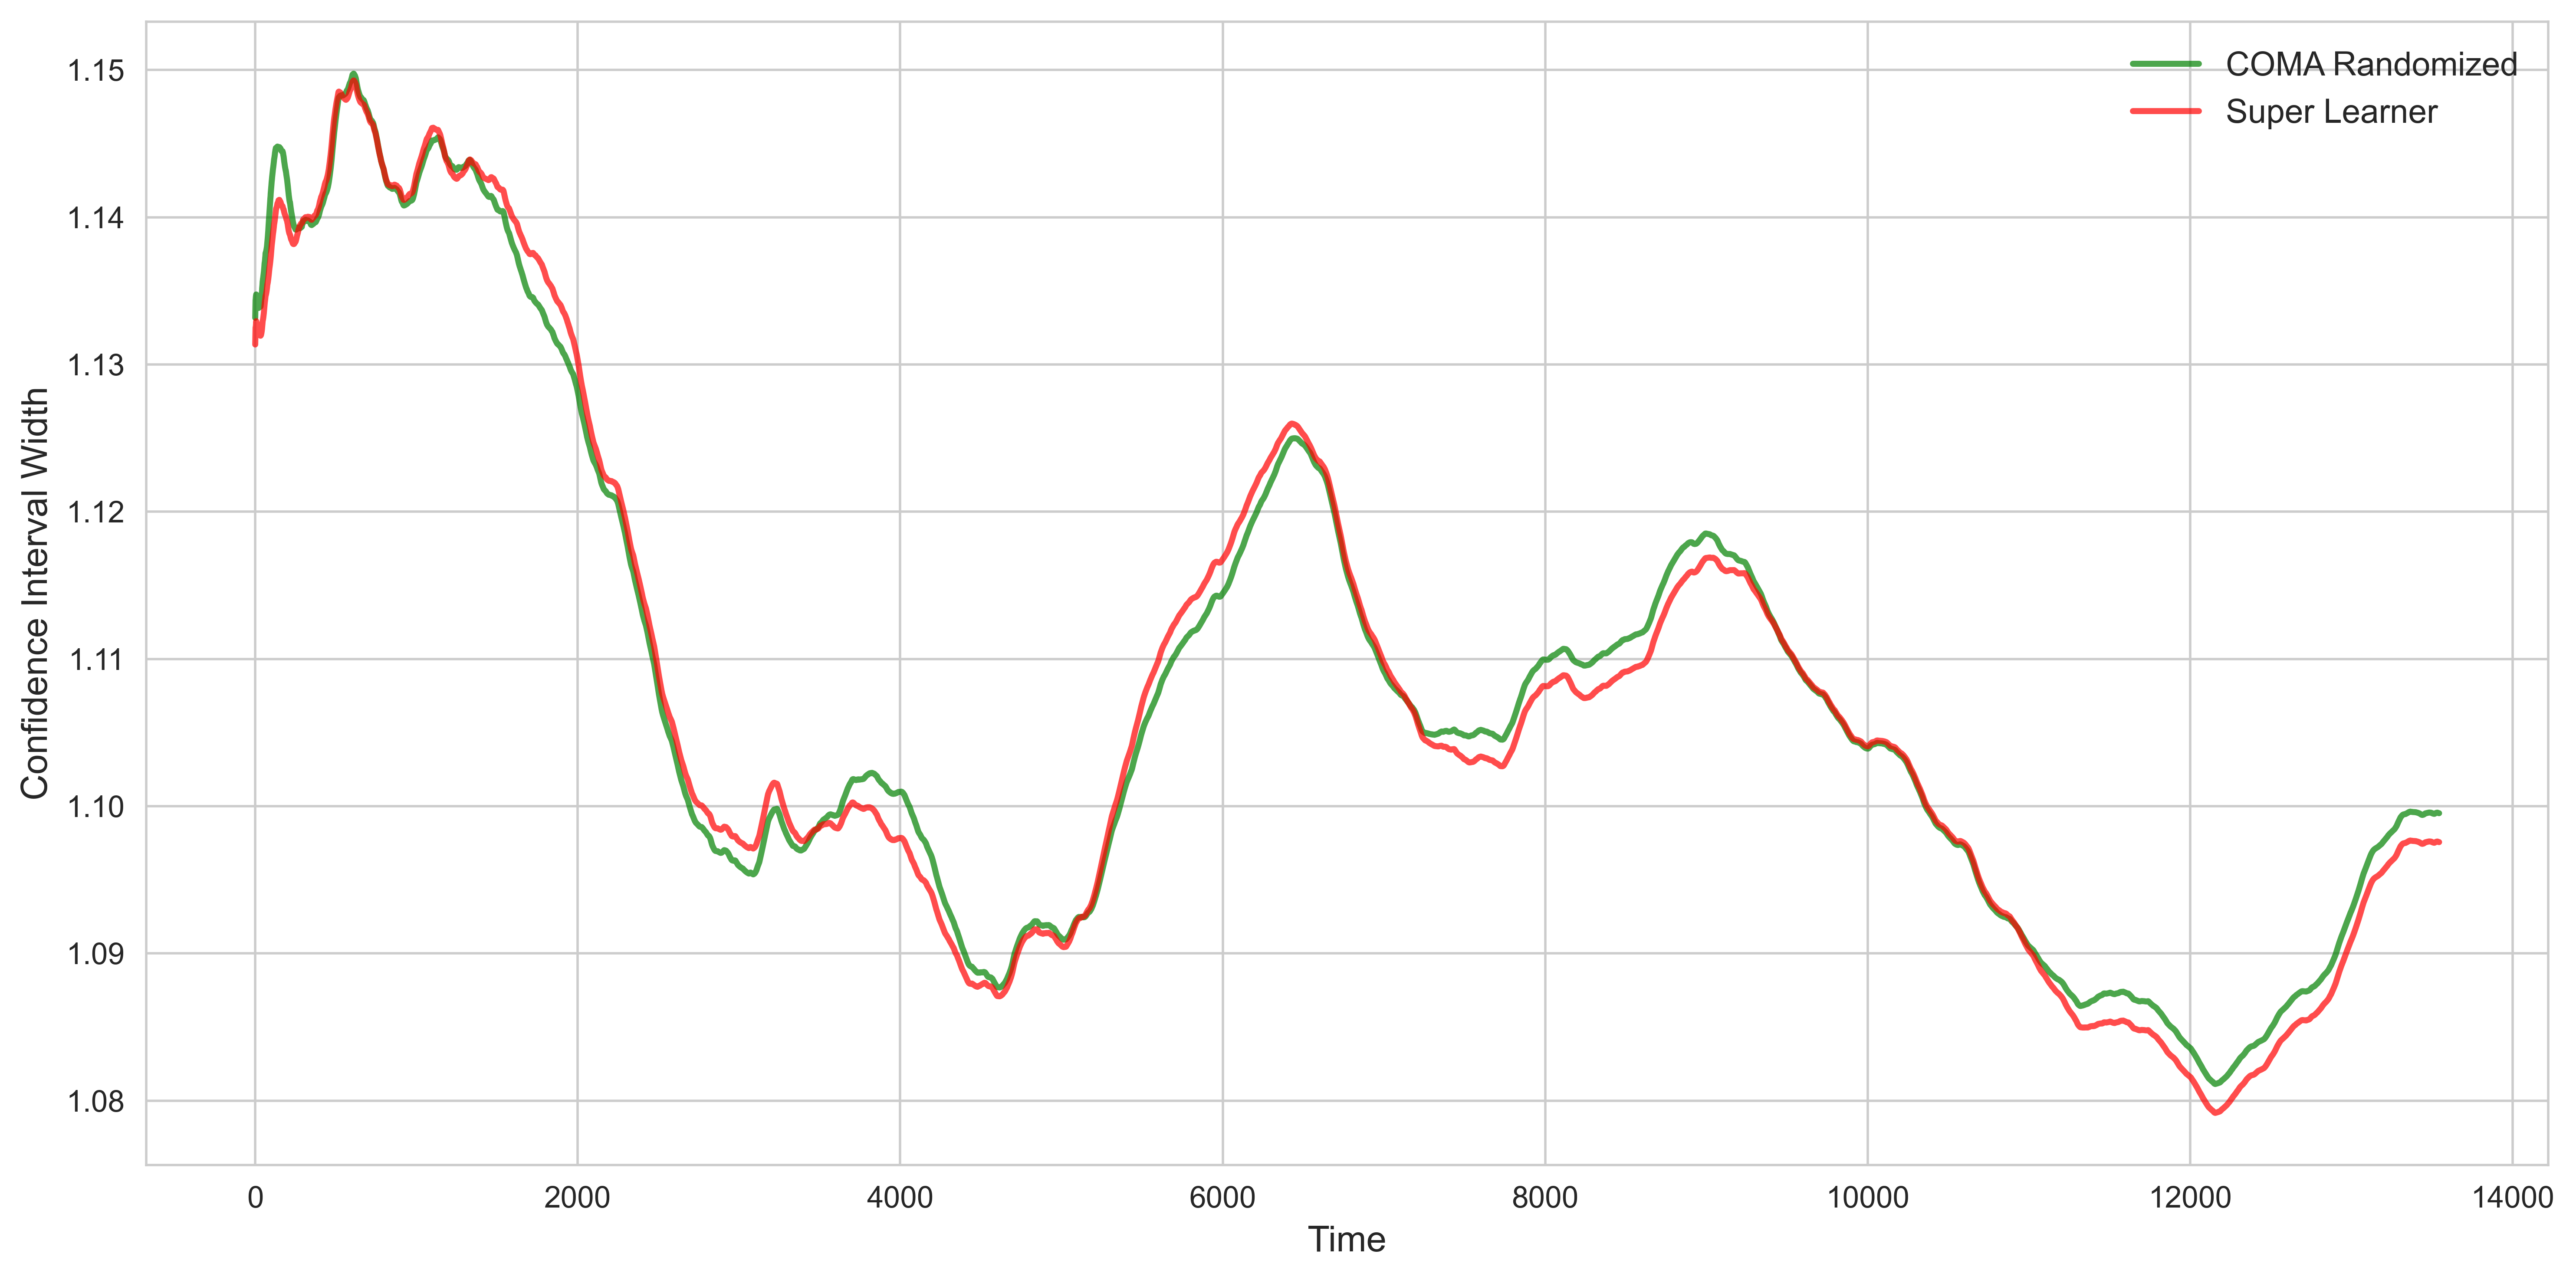

In [27]:

hedAlg_base = hedge(ci_matrix, eta=0.1)        # shape (N,3)
hedAlg_sl   = hedge(ci_matrix_sl, eta=0.1)     # shape (N,4)

weights_base = hedAlg_base["weights"]
weights_sl   = hedAlg_sl["weights"]

N_base, K_base = weights_base.shape
N_sl, K_sl   = weights_sl.shape
min_len = min(len(y_true), N_base, N_sl)
y_test_aligned = y_true[-min_len:]
pi_wm_base = []
pi_wm_sl = []


wm_cov_base = np.full(min_len, np.nan)
wm_cov_sl  = np.full(min_len, np.nan)

for i in range(min_len):
    rho_rand = np.random.uniform(0.5,1.0)

    #  Base (5 experts) 
    conf_base = np.vstack([intervals_list_plain[j][i] for j in range(5)])
    wmaj_int_base = majority_vote(conf_base, w=weights_base[i], rho=rho_rand)

    pi_wm_base.append(wmaj_int_base)
    wm_cov_base[i] = covr_fun(wmaj_int_base, y_test_aligned[i])

    # Base+SL (6 experts) 
    conf_sl = np.vstack([intervals_list_sl[j][i] for j in range(6)])
    wmaj_int_sl = majority_vote(conf_sl, w=weights_sl[i], rho=rho_rand)  # same rho_rand

    pi_wm_sl.append(wmaj_int_sl)
    wm_cov_sl[i] = covr_fun(wmaj_int_sl, y_test_aligned[i])


coma_width_rand    = np.array([loss_fun(ci) for ci in pi_wm_base])
coma_width_rand_sl = np.array([loss_fun(ci) for ci in pi_wm_sl])

print("Mean randomized coverage (COMA base):", np.nanmean(wm_cov_base))
print("Mean randomized coverage (COMA+SL):", np.nanmean(wm_cov_sl))

print("Mean CI width — COMA(base, rand):", np.nanmean(coma_width_rand))
print("Mean CI width — COMA(base+SL, rand):", np.nanmean(coma_width_rand_sl))

# plot (coma v.s sl)
plt.figure(figsize=(10, 6), dpi=500)

plt.plot(coma_width_rand, label='COMA Randomized', linewidth=2, alpha=0.7, color=colors[2])
plt.plot(CI_sl_decaying, label='Super Learner Decaying', linewidth=2, alpha=0.7, color=colors[3])

plt.xlabel('Time', fontsize=12)
plt.ylabel('Confidence Interval Width', fontsize=12)
plt.title('Confidence Interval Width Comparison', fontsize=14)

plt.legend(frameon=False, fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()

# plot (coma v.s. sl smoother)
coma_width_rand_smooth    = smooth_series(coma_width_rand, window=2000)
sl_smooth = smooth_series(CI_sl_decaying, window=2000)

plt.figure(figsize=(12, 6), dpi=500)
plt.plot(coma_width_rand_smooth, label='COMA Randomized', linewidth=2, alpha = 0.7, color='green')
plt.plot(sl_smooth, label='Super Learner', linewidth=2, alpha = 0.7, color='red')

plt.xlabel('Time', fontsize=12)
plt.ylabel('Confidence Interval Width', fontsize=12)
#plt.title("Airbnb (i.i.d, Hedge, Smoothed): CI Widths — COMA(base) vs Super Learner", fontsize=14)

plt.legend(frameon=False, fontsize=11, loc='upper right')
plt.tight_layout()
plt.savefig("iid_hedge_smooth_line_base.png", dpi=500, bbox_inches="tight")
plt.show()

### coma v.s coma + sl 

Mean randomized coverage (COMA base): 0.8998906260052757
Mean randomized coverage (COMA+SL): 0.8994402624975874
Mean CI width — COMA(base, rand): 1.1095099560375237
Mean CI width — COMA(base+SL, rand): 1.1070596897562346


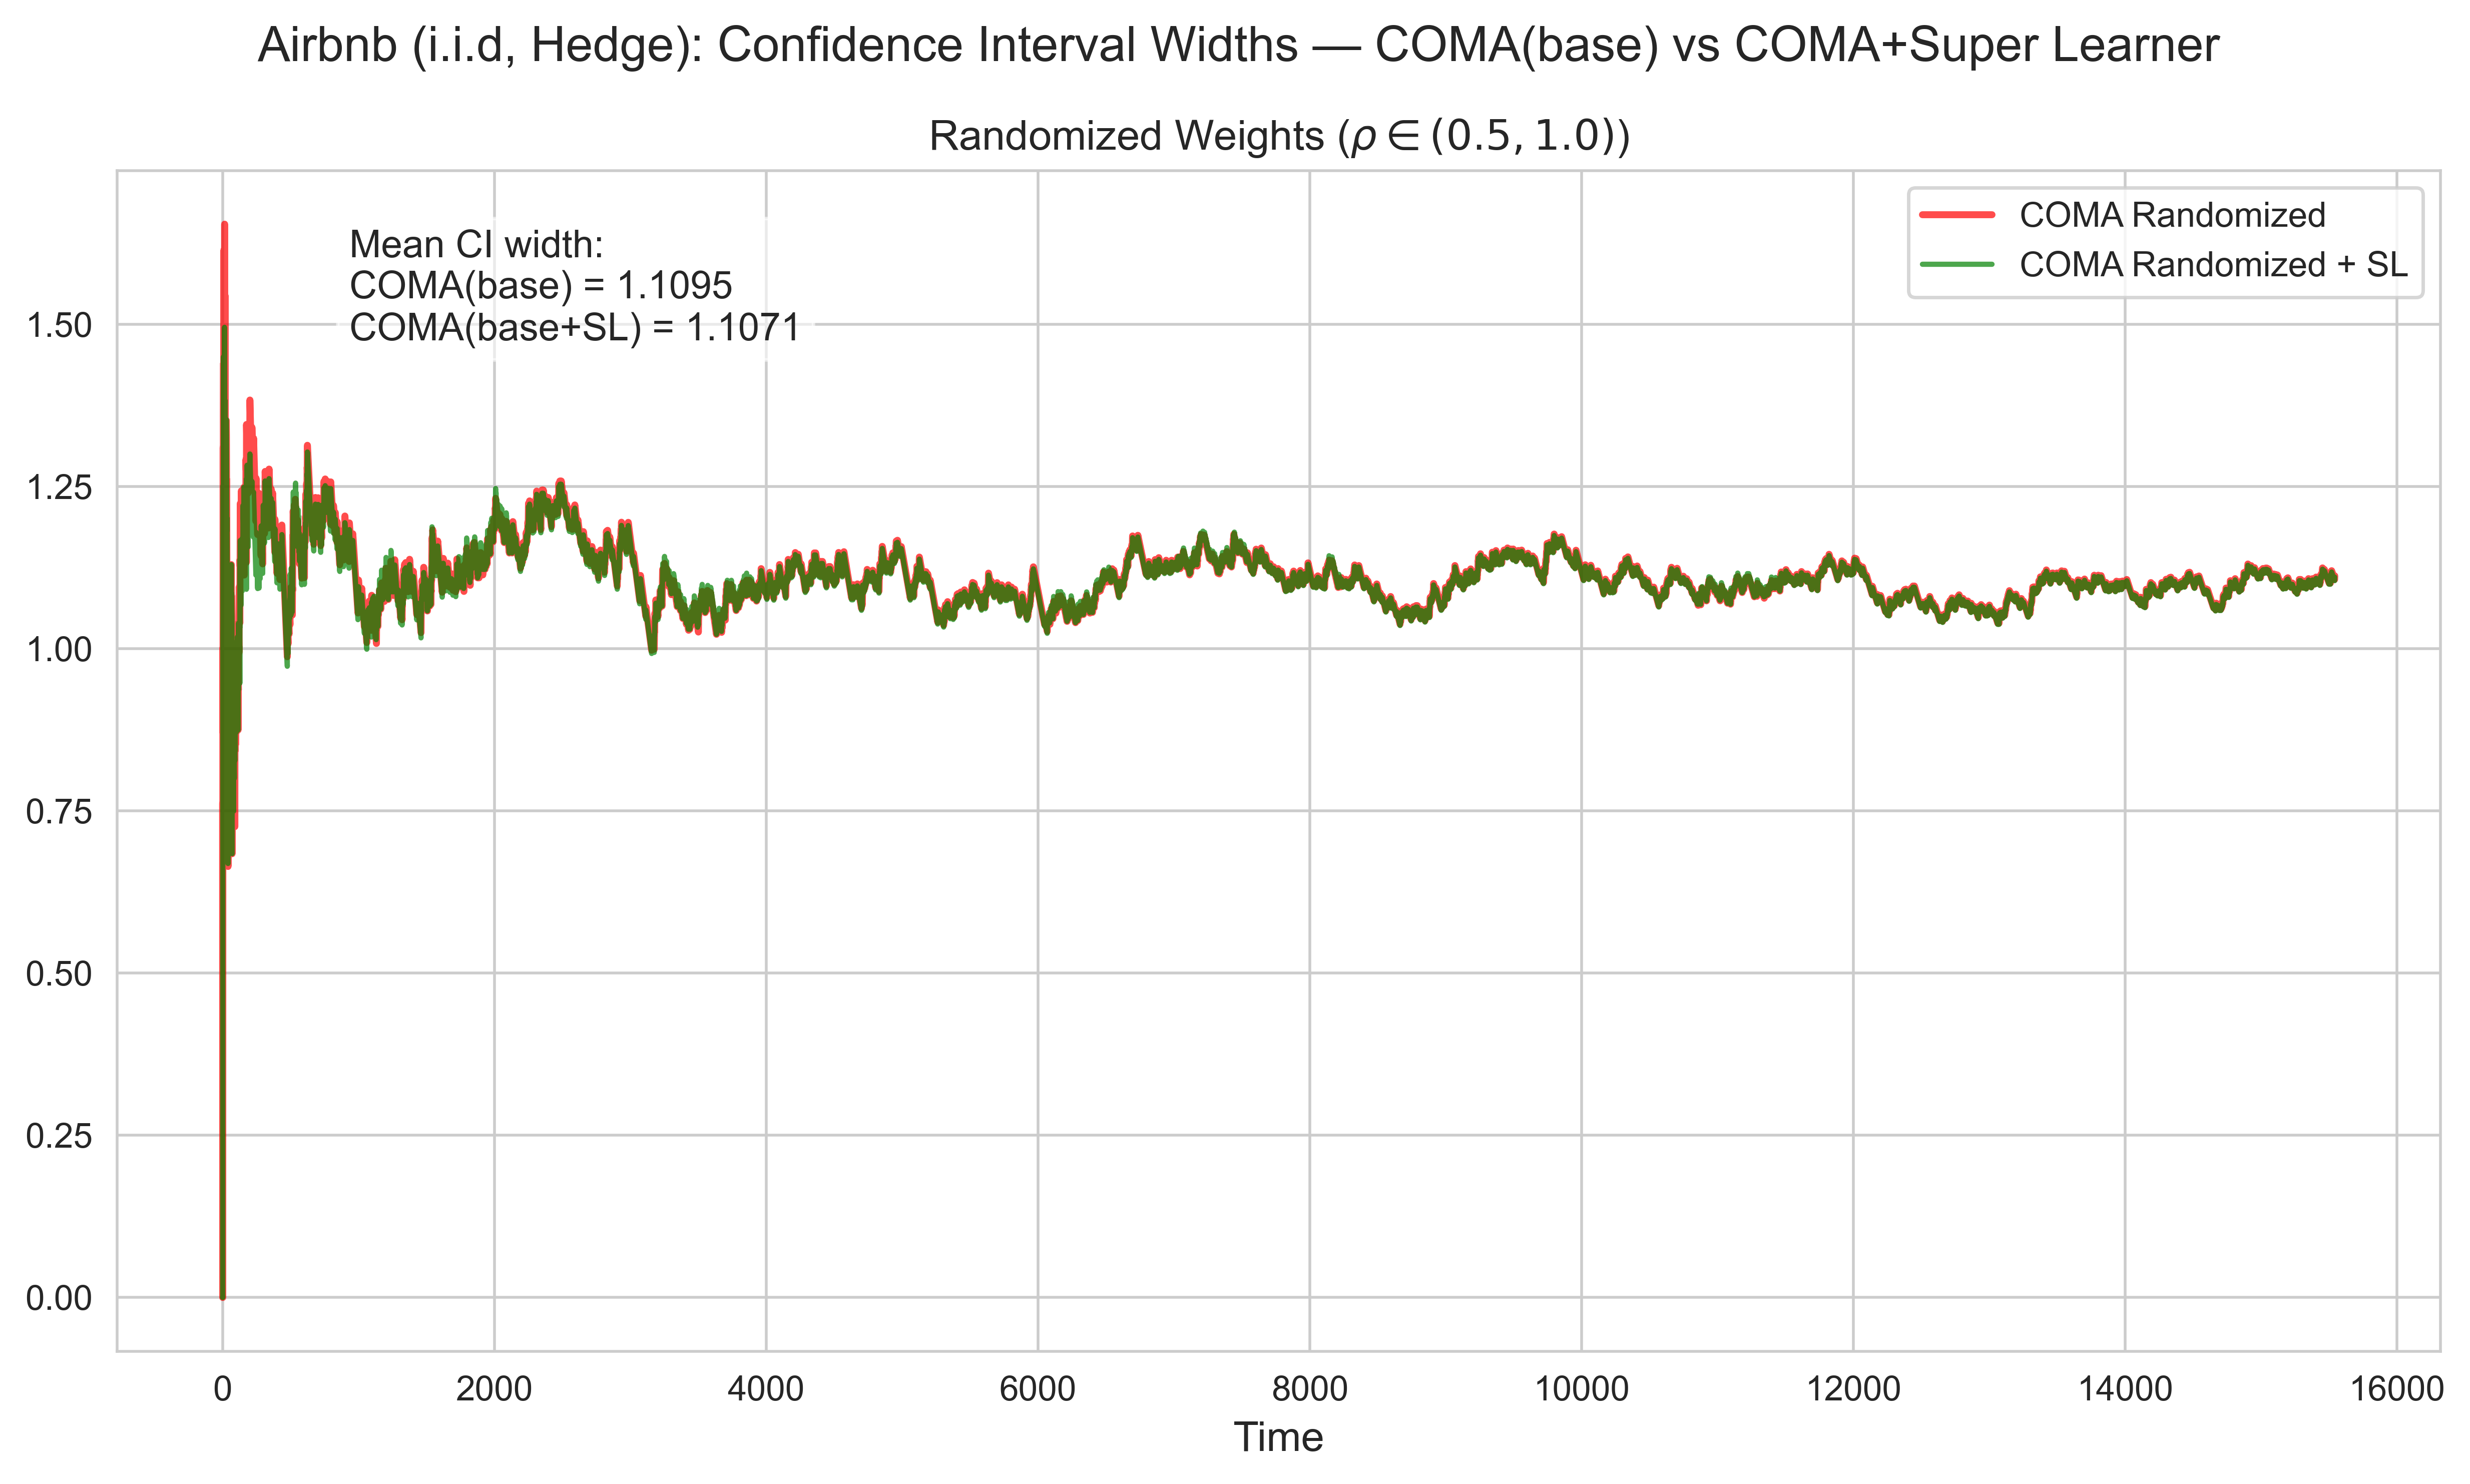

In [18]:

coma_width_rand    = np.array([loss_fun(ci) for ci in pi_wm_base])
coma_width_rand_sl = np.array([loss_fun(ci) for ci in pi_wm_sl])


print("Mean randomized coverage (COMA base):", np.nanmean(wm_cov_base))
print("Mean randomized coverage (COMA+SL):", np.nanmean(wm_cov_sl))

print("Mean CI width — COMA(base, rand):", np.nanmean(coma_width_rand))
print("Mean CI width — COMA(base+SL, rand):", np.nanmean(coma_width_rand_sl))


#  Randomized subplot
plt.figure(figsize=(10, 6), dpi=500)
plt.plot(coma_width_rand, label='COMA Randomized', linewidth=2, alpha=0.7, color='red')
plt.plot(coma_width_rand_sl, label='COMA Randomized + SL', linewidth=1.5, alpha=0.7, color='green')
plt.title("Randomized Weights ($\\rho \\in (0.5,1.0)$)", fontsize=12)
plt.xlabel("Time", fontsize=12)
plt.legend()

# Annotate means
mean_rand = np.nanmean(coma_width_rand)
mean_rand_sl = np.nanmean(coma_width_rand_sl)
plt.text(0.1, 0.95,
         f"Mean CI width:\nCOMA(base) = {mean_rand:.4f}\nCOMA(base+SL) = {mean_rand_sl:.4f}",
         transform=plt.gca().transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

plt.suptitle("Airbnb (i.i.d, Hedge): Confidence Interval Widths — COMA(base) vs COMA+Super Learner", fontsize=14)
plt.tight_layout()
plt.savefig("iid_hedge_line_comasl.png", dpi=500, bbox_inches="tight")
plt.show()

##### boxplot

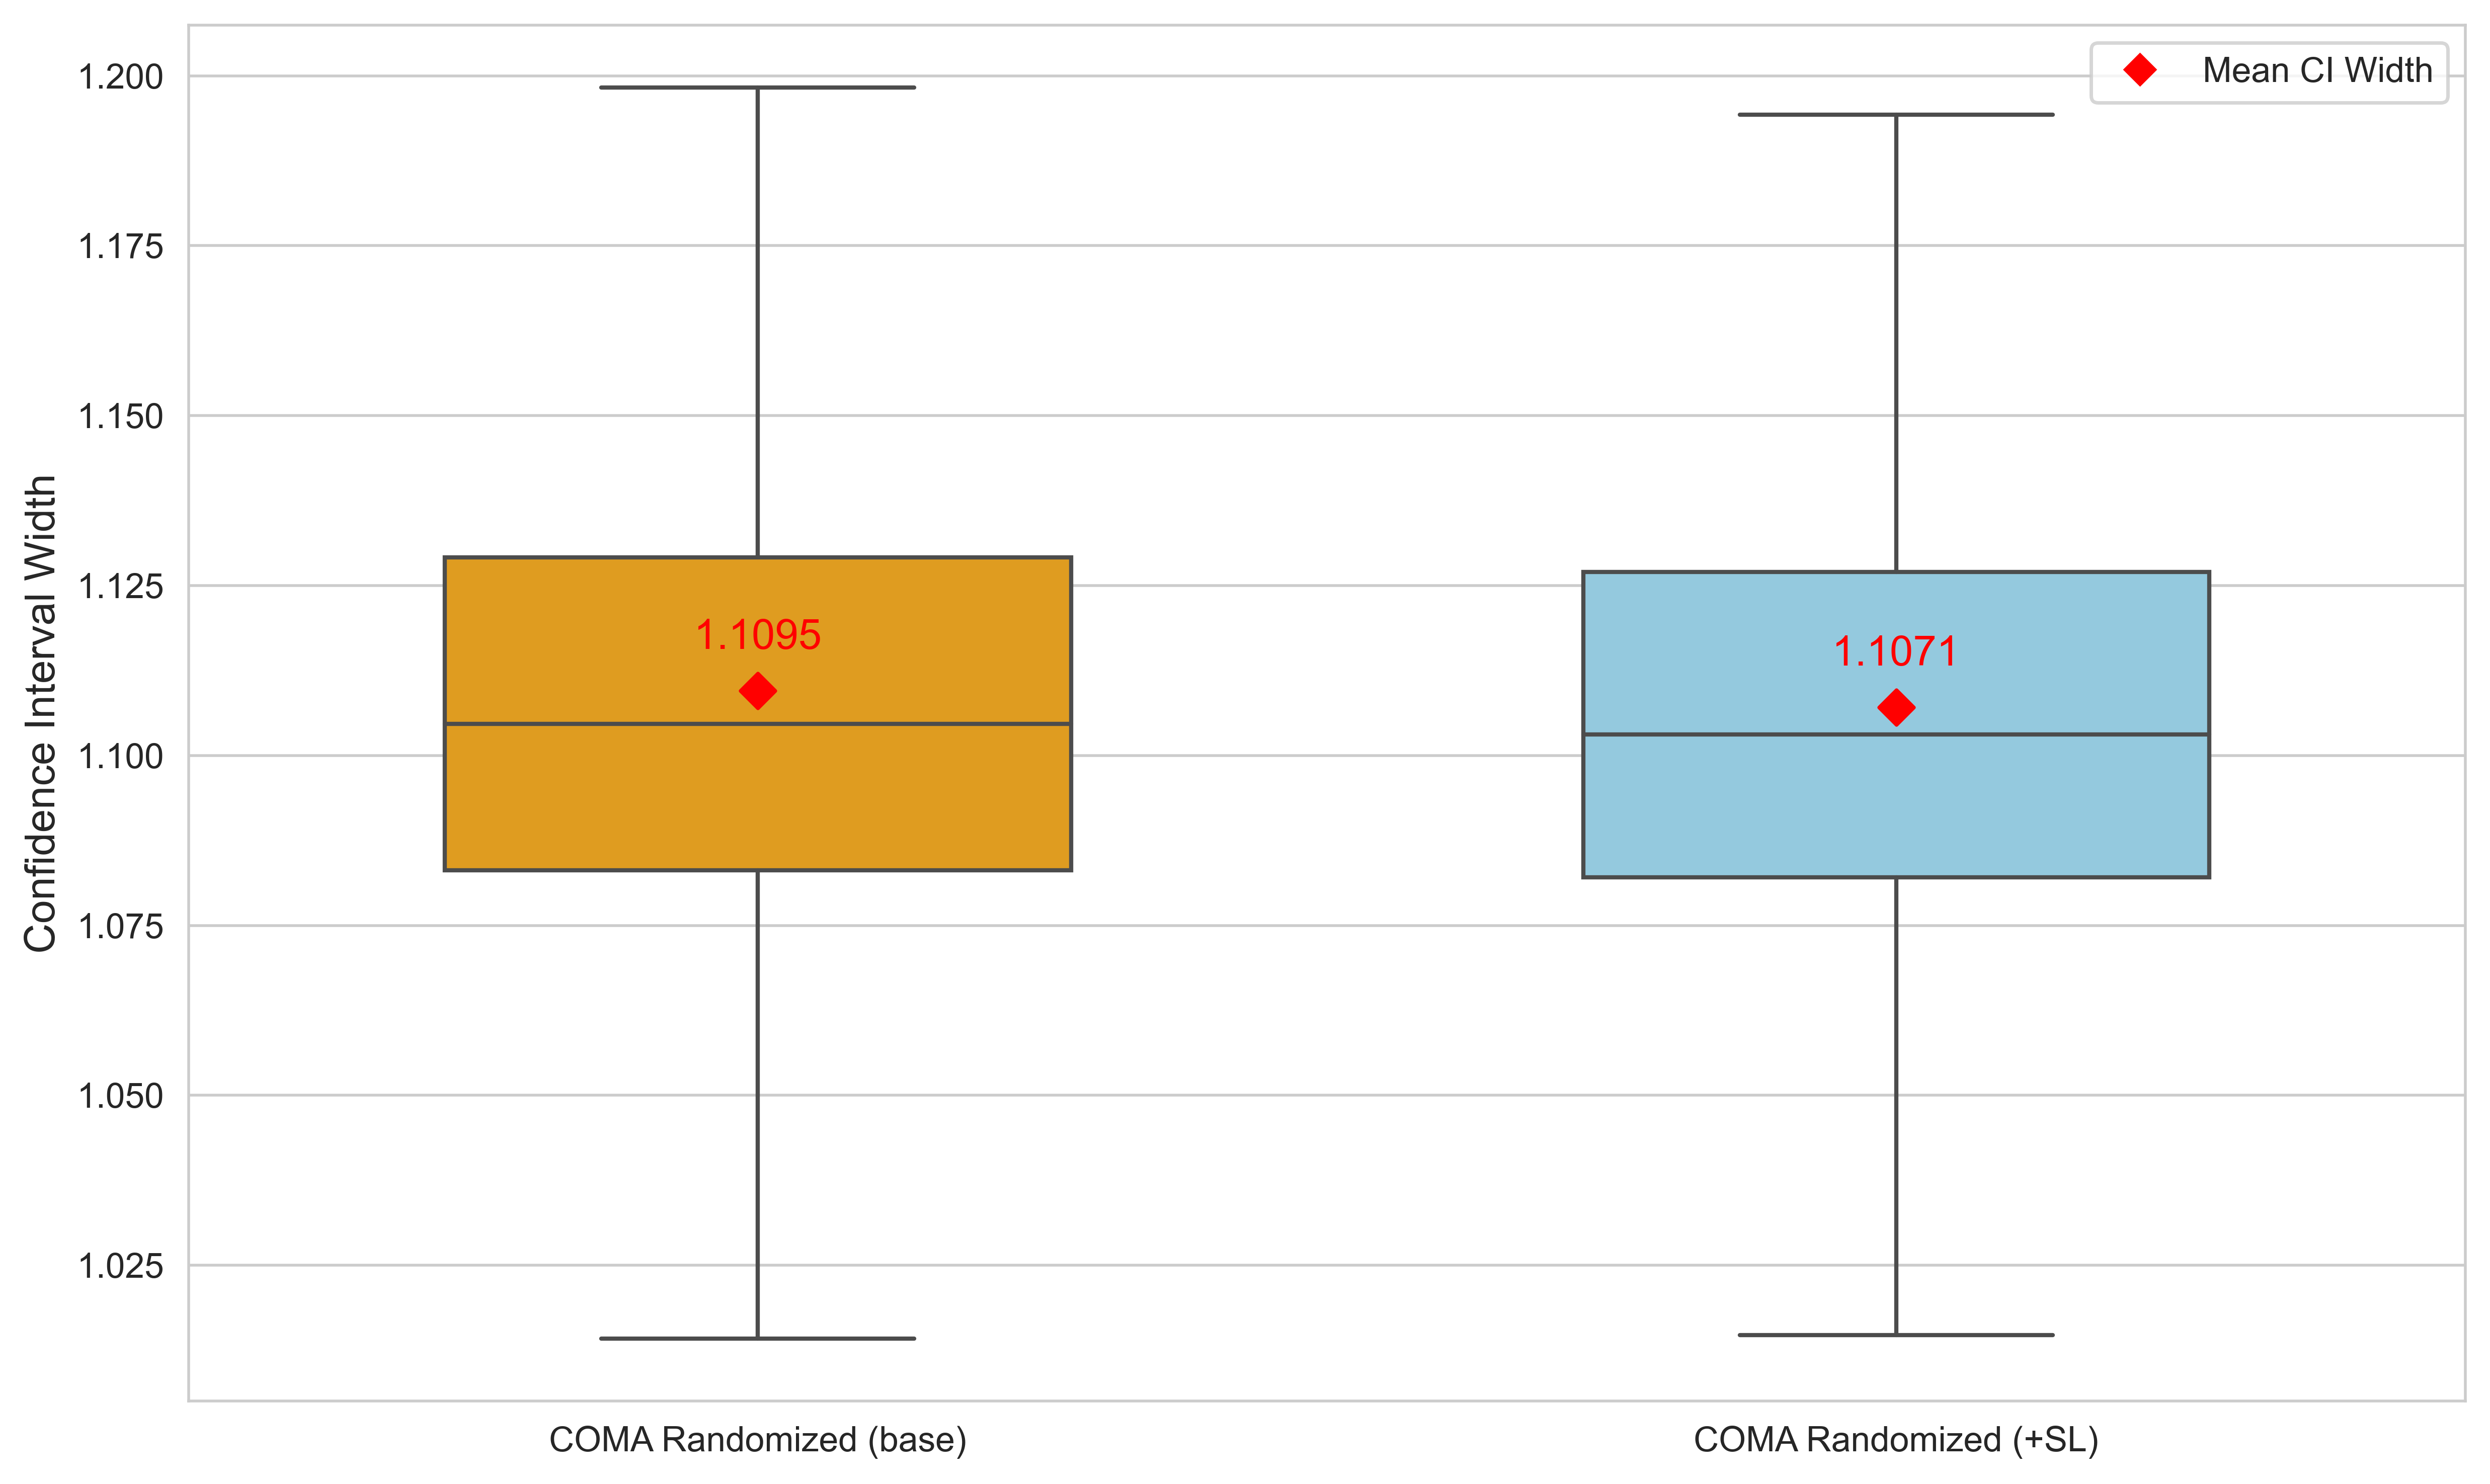

In [19]:
data_dict = {
    "COMA Randomized (base)": coma_width_rand,
    "COMA Randomized (+SL)": coma_width_rand_sl
}

df_box = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data_dict.items()]))
df_long = df_box.melt(var_name="Method", value_name="CI Width")
rand_methods = ["COMA Randomized (base)", "COMA Randomized (+SL)"]

palette = {"COMA Randomized (base)": "orange",
           "COMA Randomized (+SL)": "skyblue"}

plt.figure(figsize=(10, 6), dpi=500)

# Boxplot (randomized methods only)
sns.boxplot(
    x="Method",
    y="CI Width",
    data=df_long[df_long["Method"].isin(rand_methods)],
    order=rand_methods,
    palette=palette,
    showfliers=False,
    width=0.55,
    linewidth=1.2
)

# Mean CI width (red diamonds)
means_rand = [np.nanmean(data_dict[m]) for m in rand_methods]
for i, m in enumerate(rand_methods):
    plt.scatter(i, means_rand[i], color="red", marker="D", s=50, zorder=3)
    plt.text(
        i,
        means_rand[i] + 0.005,
        f"{means_rand[i]:.4f}",
        ha="center",
        va="bottom",
        fontsize=12,
        color="red"
    )

plt.xlabel("")
plt.ylabel("Confidence Interval Width", fontsize=12)
plt.legend(
    handles=[plt.Line2D([0], [0], color="red", marker="D",
                        linestyle="", label="Mean CI Width")],
    loc="upper right"
)

#plt.suptitle("Airbnb(i.i.d, Hedge): Boxplot of CI Widths — COMA(base) vs COMA+Super Learner", fontsize=14)
plt.tight_layout()
plt.savefig("iid_hedge_boxplot_comasl.png", dpi=500, bbox_inches="tight")
plt.show()

##### smooth

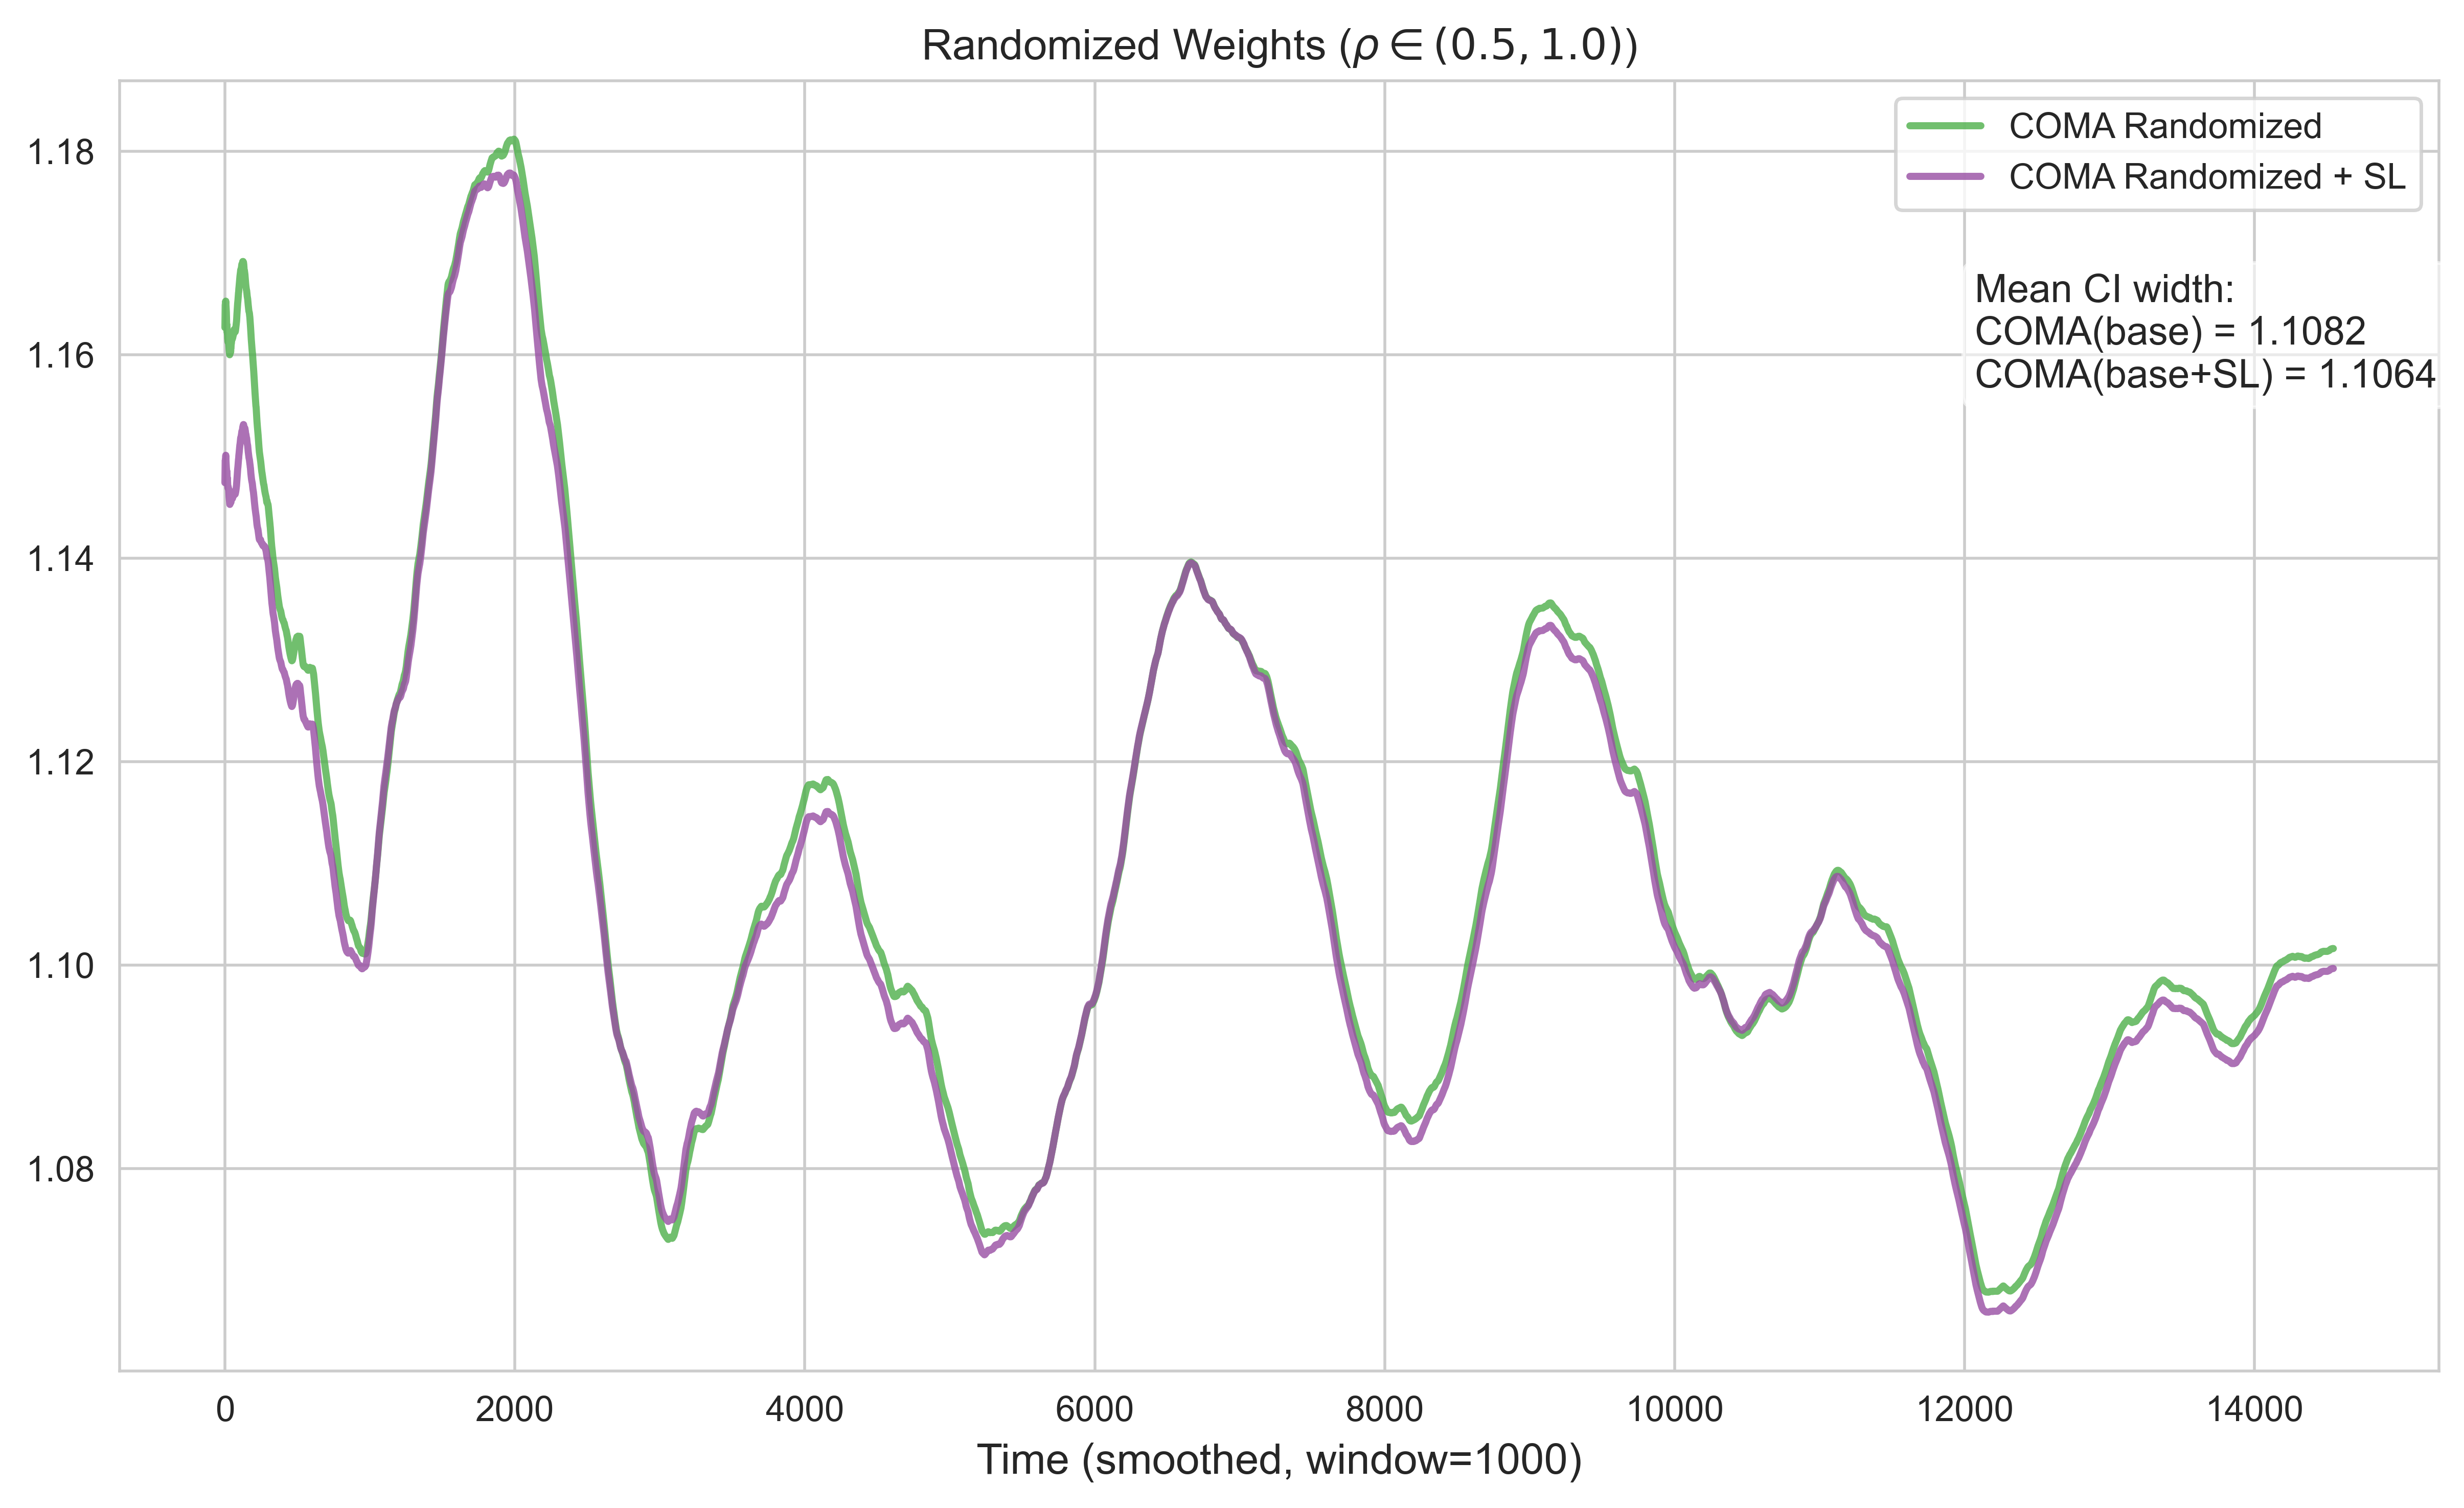

In [30]:

coma_width_rand_smooth    = smooth_series(coma_width_rand, window=1000)
coma_width_rand_sl_smooth = smooth_series(coma_width_rand_sl, window=1000)

# Randomized subplot 
plt.figure(figsize=(10, 6), dpi=500)
plt.plot(coma_width_rand_smooth, label='COMA Randomized', linewidth=2, alpha=0.8, color=colors[2])
plt.plot(coma_width_rand_sl_smooth, label='COMA Randomized + SL', linewidth=2, alpha=0.8, color=colors[3])
plt.title("Randomized Weights ($\\rho \\in (0.5,1.0)$)", fontsize=12)
plt.xlabel("Time (smoothed, window=1000)", fontsize=12)
plt.legend()
mean_rand = np.nanmean(coma_width_rand_smooth)
mean_rand_sl = np.nanmean(coma_width_rand_sl_smooth)
plt.text(0.8, 0.85,
         f"Mean CI width:\nCOMA(base) = {mean_rand:.4f}\nCOMA(base+SL) = {mean_rand_sl:.4f}",
         transform=plt.gca().transAxes,
         fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

#plt.suptitle("Airbnb (i.i.d, Hedge, Smoothed): CI Widths — COMA(base) vs COMA+Super Learner", fontsize=14)
plt.tight_layout()
plt.savefig("iid_hedge_smooth_line_comasl.png", dpi=500, bbox_inches="tight")
plt.show()